### 📖  Оглавление

- [1. Обзор признаков](#обзор-признаков-и-общих-характеристик)
- [2. Анализ пропущенных значений](#анализ-пропущенных-значений)
- [3. Обработка пропущенных значений](#-3-обработка-пропущенных-значений)
- [4. Анализ выбросов](#-4-анализ-выбосов)
- [5. Обработка категориальных данных](#-5-обработка-категориальных-данных)
- [6. Обработка выбросов](#-6-обработка-выбросов)
- [7. Масштабирование](#-7-масштабирование-и-нормализация-данных)
- [8. Восстановление дисбаланса](#-8-восстановление-дисбаланса-классов)
- [9. Поиск распределения](#-9-поиск-распределения)
- [10. Корреляционный анализ](#-10-корреляционный-анализ)
- [11. Обучение моделей](#-11-обучение-моделей)
- [12. Результаты обучения](#-12-результаты-обучения)

Примечание: пункт с дубликатами включен в обзор признаков <br>
Ссылка на датасет: https://www.kaggle.com/datasets/yasserh/loan-default-dataset/data

In [1]:
%reset -f

In [2]:
from IPython.core.interactiveshell import InteractiveShell # type: ignore
InteractiveShell.ast_node_interactivity = 'none' # 'last_expr' # Настраиваем отображение всех результатов в ячейке

In [ ]:
# import kagglehub
# Download latest version
# path = kagglehub.dataset_download("yasserh/loan-default-dataset")
# print("Path to dataset files:", path)

import pandas as pd # type: ignore
import missingno as msno # type: ignore

path = ".../datasets/yasserh/loan-default-dataset/versions/1" # Ввести свой путь к датасету
df = pd.read_csv(path + "/Loan_Default.csv")

# print(df.head())
print(df.shape)

(148670, 34)


Посмотрим на дубликаты <br>
Видим, что полных дубликатов по все строкам и столбцам нету.

In [4]:
df_test = df.copy().drop(columns=["ID"])

print("Всего полных дубликатов по строкам:", df_test.duplicated().sum())
# print("Всего полных дубликатов по столбцам:", df_test.T.duplicated().sum()) # - тоже 0, долго работает

num_rows_with_nan = df.isnull().any(axis=1).sum()
print("Всего уникальных строк с NaN:", num_rows_with_nan)

Всего полных дубликатов по строкам: 0
Всего уникальных строк с NaN: 50483


In [ ]:
print(df.dtypes)
print(df.dtypes.value_counts())

ID                             int64
year                           int64
loan_limit                    object
Gender                        object
approv_in_adv                 object
loan_type                     object
loan_purpose                  object
Credit_Worthiness             object
open_credit                   object
business_or_commercial        object
loan_amount                    int64
rate_of_interest             float64
Interest_rate_spread         float64
Upfront_charges              float64
term                         float64
Neg_ammortization             object
interest_only                 object
lump_sum_payment              object
property_value               float64
construction_type             object
occupancy_type                object
Secured_by                    object
total_units                   object
income                       float64
credit_type                   object
Credit_Score                   int64
co-applicant_credit_type      object
a

### 🚓 1. Обзор признаков и общих характеристик

<style>
    table { font-size: 13px; } /* Уменьшаем шрифт */
</style>

**Количество строк**: `148670` <br>
**Количество столбцов**: `34`<br>
**Количество полных дублей**: `0` <br>
**Всего уникальных строк с NaN**: `50483`

<br>

| Тип данных | Кол-во |
|------------|--------|
| object64 | 21 |
| float64 | 8 |
| int | 5 | 


In [6]:
# Проверка пропущенных значений для каждого столбца
missing_values = df.isnull().sum()

missing_percent = (missing_values / len(df)) * 100  # Вычисляем процент пропусков
missing_info = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percent
})

# Фильтруем только те столбцы, где есть пропуски
missing_info = missing_info[missing_info['Missing Values'] > 0]
print(missing_info)


                           Missing Values  Percentage
loan_limit                           3344    2.249277
approv_in_adv                         908    0.610749
loan_purpose                          134    0.090133
rate_of_interest                    36439   24.509989
Interest_rate_spread                36639   24.644515
Upfront_charges                     39642   26.664425
term                                   41    0.027578
Neg_ammortization                     121    0.081388
property_value                      15098   10.155378
income                               9150    6.154571
age                                   200    0.134526
submission_of_application             200    0.134526
LTV                                 15098   10.155378
dtir1                               24121   16.224524


In [7]:
print(df.info()) # Ещё раз проверка данных

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10



<style>
    table { font-size: 13px; } /* Уменьшаем шрифт */
</style>

#### 🌟 Основные данные  
| Переменная | Описание | Тип данных | Пропуски |
|------------|----------|------------|------------------|
| ID       | ID заявки на кредит клиента | int | 0 |
| year    | Год подачи заявки | int | 0 |
| Status | Просрочен ли кредит (1 - да, 0 - нет) | int | 0 |


#### 👤 Информация о заемщике  
| Переменная | Описание | Тип данных | Пропуски |
|------------|----------|------------|------------------|
| age | Возраст заявителя | int | 200 |
| Gender   | Пол заявителя (male, female, joint, sex not available) | object | 0 |
| open_credit | Есть ли у заявителя открытые кредиты <br> (opc - да, nopc - нет) | object | 0 |
| income | Годовой доход заявителя | float | 9150 |
| Credit_Score | Кредитный рейтинг | int | 0 |
| credit_type | Тип кредитной информации заявителя (CIB, CRIF, EXP, EQUI) | object | 0 |
| co-applicant_credit_type | Кредитной информации созаемщика (CIB, EXP) | object | 0 |
| Credit_Worthiness | Кредитоспособность (l1, l2) | object | 0 |




#### 💳 Условия кредита  
| Переменная | Описание | Тип данных | Пропуски |
|------------|----------|------------|------------------|
| loan_type | Тип кредита (type1, type2, type3) | object | 0 |
| loan_purpose | Цель кредита (p1, p2, p3, p4) | object | 134 |
| business_or_commercial | Для каких целей предназначен кредит <br> (ob/c - бизнес, nob/c - личный) | object | 0 |
| loan_amount | Сумма кредита | int | 0 |
| rate_of_interest | Процентная ставка | float | 36439 |
| Neg_ammortization | Допускает ли кредит отрицательную амортизацию <br> (neg_amm - да, not_neg - нет) | object | 121 |
| term | Срок кредита (в месяцах) | float | 41 |
| loan_limit | Ограничение по кредиту (cf - соответствует требованиям, ncf - нет) | object | 3344 |
| approv_in_adv | Был ли кредит одобрен заранее (pre - да, nopre - нет) | object | 908 |
| Interest_rate_spread | Разница процентной ставки и базовой ставки | float | 36639 |
| Upfront_charges | Первоначальные комиссии, связанная с обеспечением кредита | float | 39642
| interest_only | Допускает ли вариант выплаты только процентов <br> (int_only - да, not_int - нет) | object | 0 |
| lump_sum_payment | Требуется ли единовременный платеж в конце <br> (lpsm - да, not_lpsm - нет) | object | 0 |
| submission_of_application | Как подана заявка (to_inst - в банк, not_inst - нет) | object | 200 | 
| LTV | Коэффициент кредита к стоимости (LTV) <br> (кредитная сумма / стоимость недвижимости) | float | 15098 |
| dtir1 | Коэффициент долга к доходу (DTI), соотношение долга от доходу | float | 24121 |

#### 🏠 Недвижимость и залог  
| Переменная | Описание | Тип данных | Пропуски |
|------------|----------|------------|------------------|
| property_value | Стоимости недвижимости, финансируемой по кредиту | float | 15098 |
| construction_type | Тип постройки (sb - капитальная, mh - мобильный дом) | object | 0 |
| occupancy_type | Тип использования (pr - основное жилье, sr - вторичное, ir - инвестиции) | object | 0 |
| Region | Регион недвижимости (North, South, Central, North-East) | object | 0 |
| Secured_by | Тип залога (home - дом, land - земля) | object | 0 |
| total_units | Количество единиц в финансируемой недвижимости (1U, 2U, 3U, 4U) | object | 0 | 
| Security_Type | Тип обеспечения или залога (direct - прямой, indirect - косвенный) | object | 0 |

<br>


#### Считаем начальное соотношение классов
<small>
Целевая переменная в данном случае — это status. Она указывает, произошел ли дефолт по кредиту (например, 1 — дефолт, 0 — нет). <br>
Это идеальная переменная для построения модели классификации, которая будет предсказывать вероятность дефолта на основе других признаков.
</small>

In [8]:

print(df['Status'].unique())

mask1 = df[df['Status'] == 1]
mask2 = df[df['Status'] == 0]

true1 = mask1.shape[0] / (df.shape[0]) # 1
false1 = mask2.shape[0] / (df.shape[0]) # 0
print(f'{true1 * 100:.2f}%, {false1 * 100:.2f}%') # Соотношение классов

[1 0]
24.64%, 75.36%


<small>
Начальное соотношение положительных и отрицательных классов целевой переменной. <br>
24.64 % на 75,36% - могут возникнуть сложности, требуется пересчитать после всей обработки данных. <br>

Проблемы что могут возникнуть:

1. Смещение модели
2. Проблемы с метриками
</small>

###  🚚 2. Анализ пропущенных значений

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


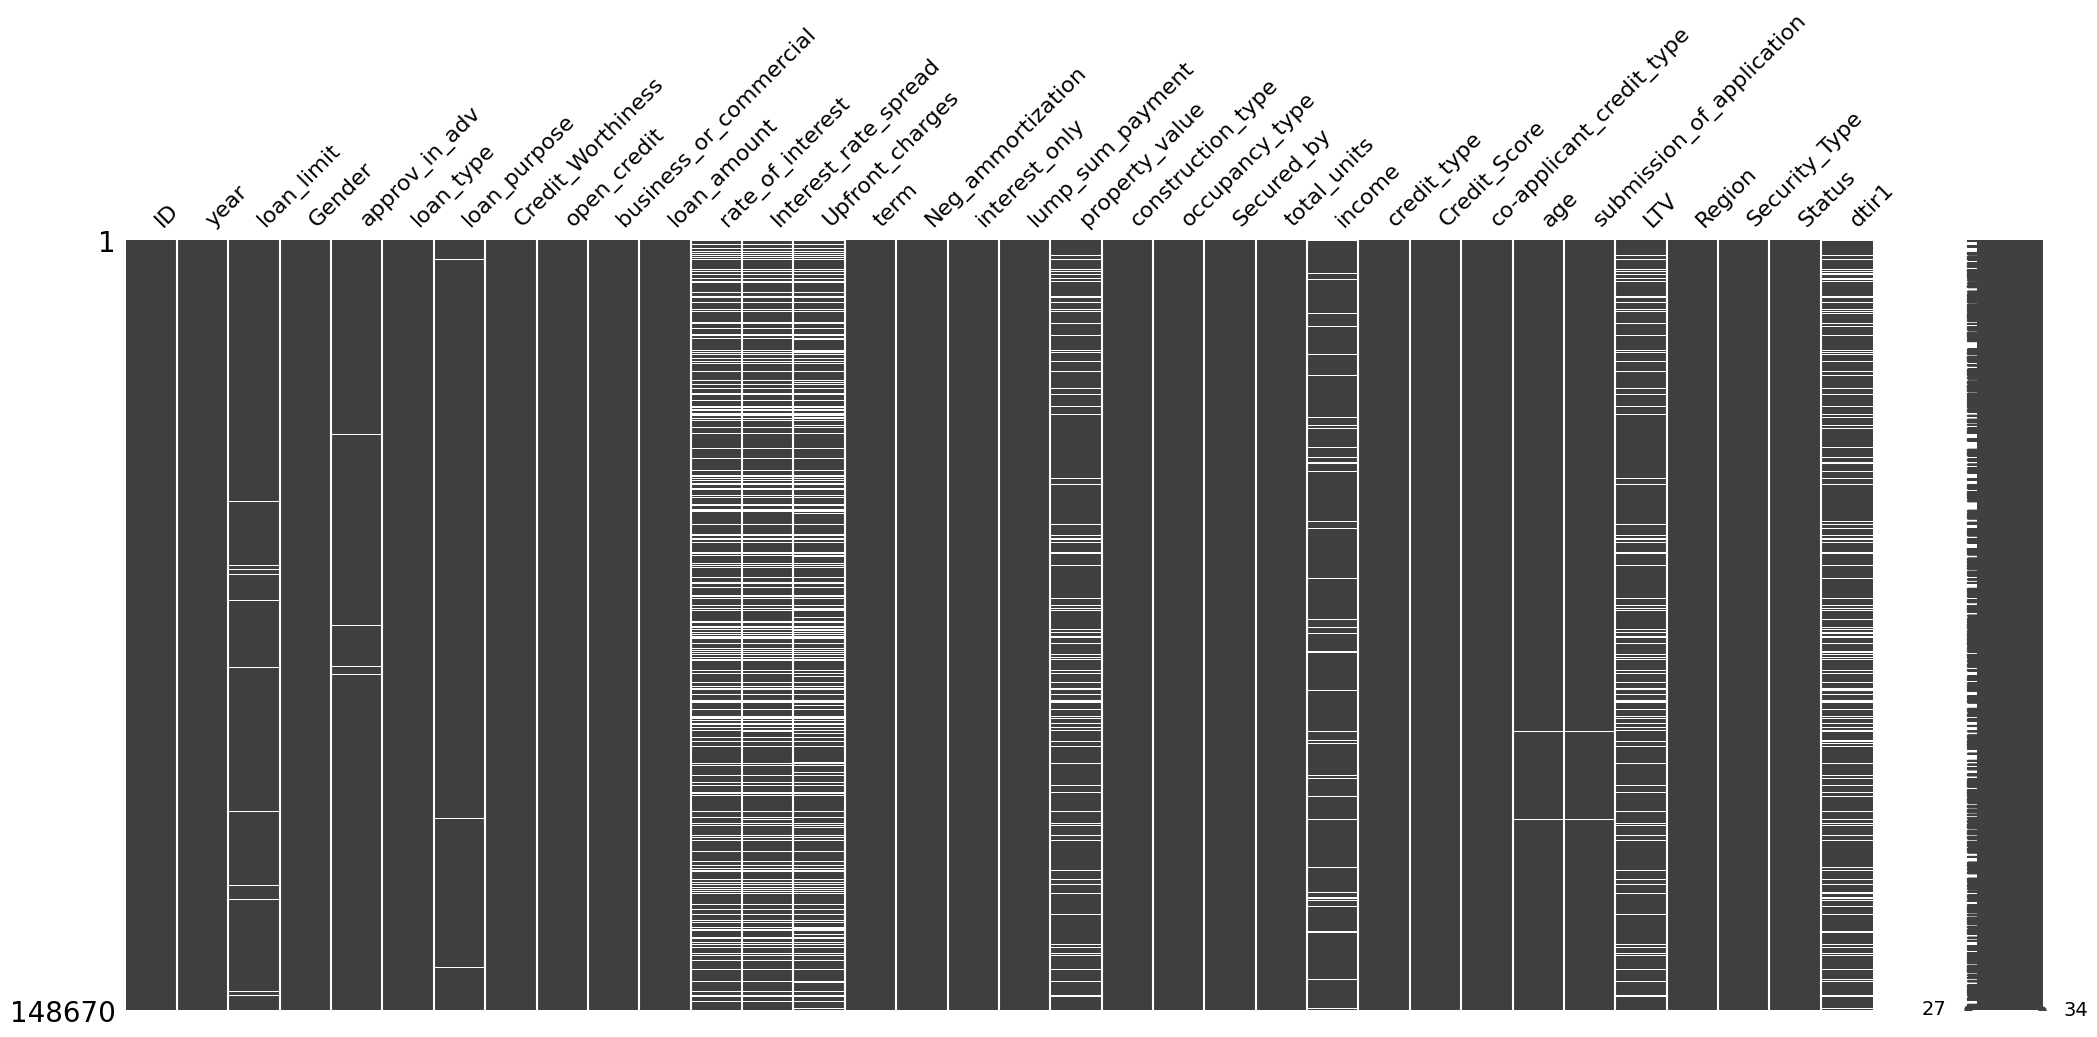

<Figure size 1500x900 with 0 Axes>

In [9]:
%pip install matplotlib
import matplotlib.pyplot as plt

msno.matrix(df)
plt.figure(figsize = (15,9))
plt.show()


<span style="font-size: 18px;">  На верхнем графике мы видим визуализацию пропусков: чем больше белых линий, тем больше пропущенных значений. Наибольшее количество пропусков приходится на столбцы с первоначальной комиссией и процентной ставкой. </span>


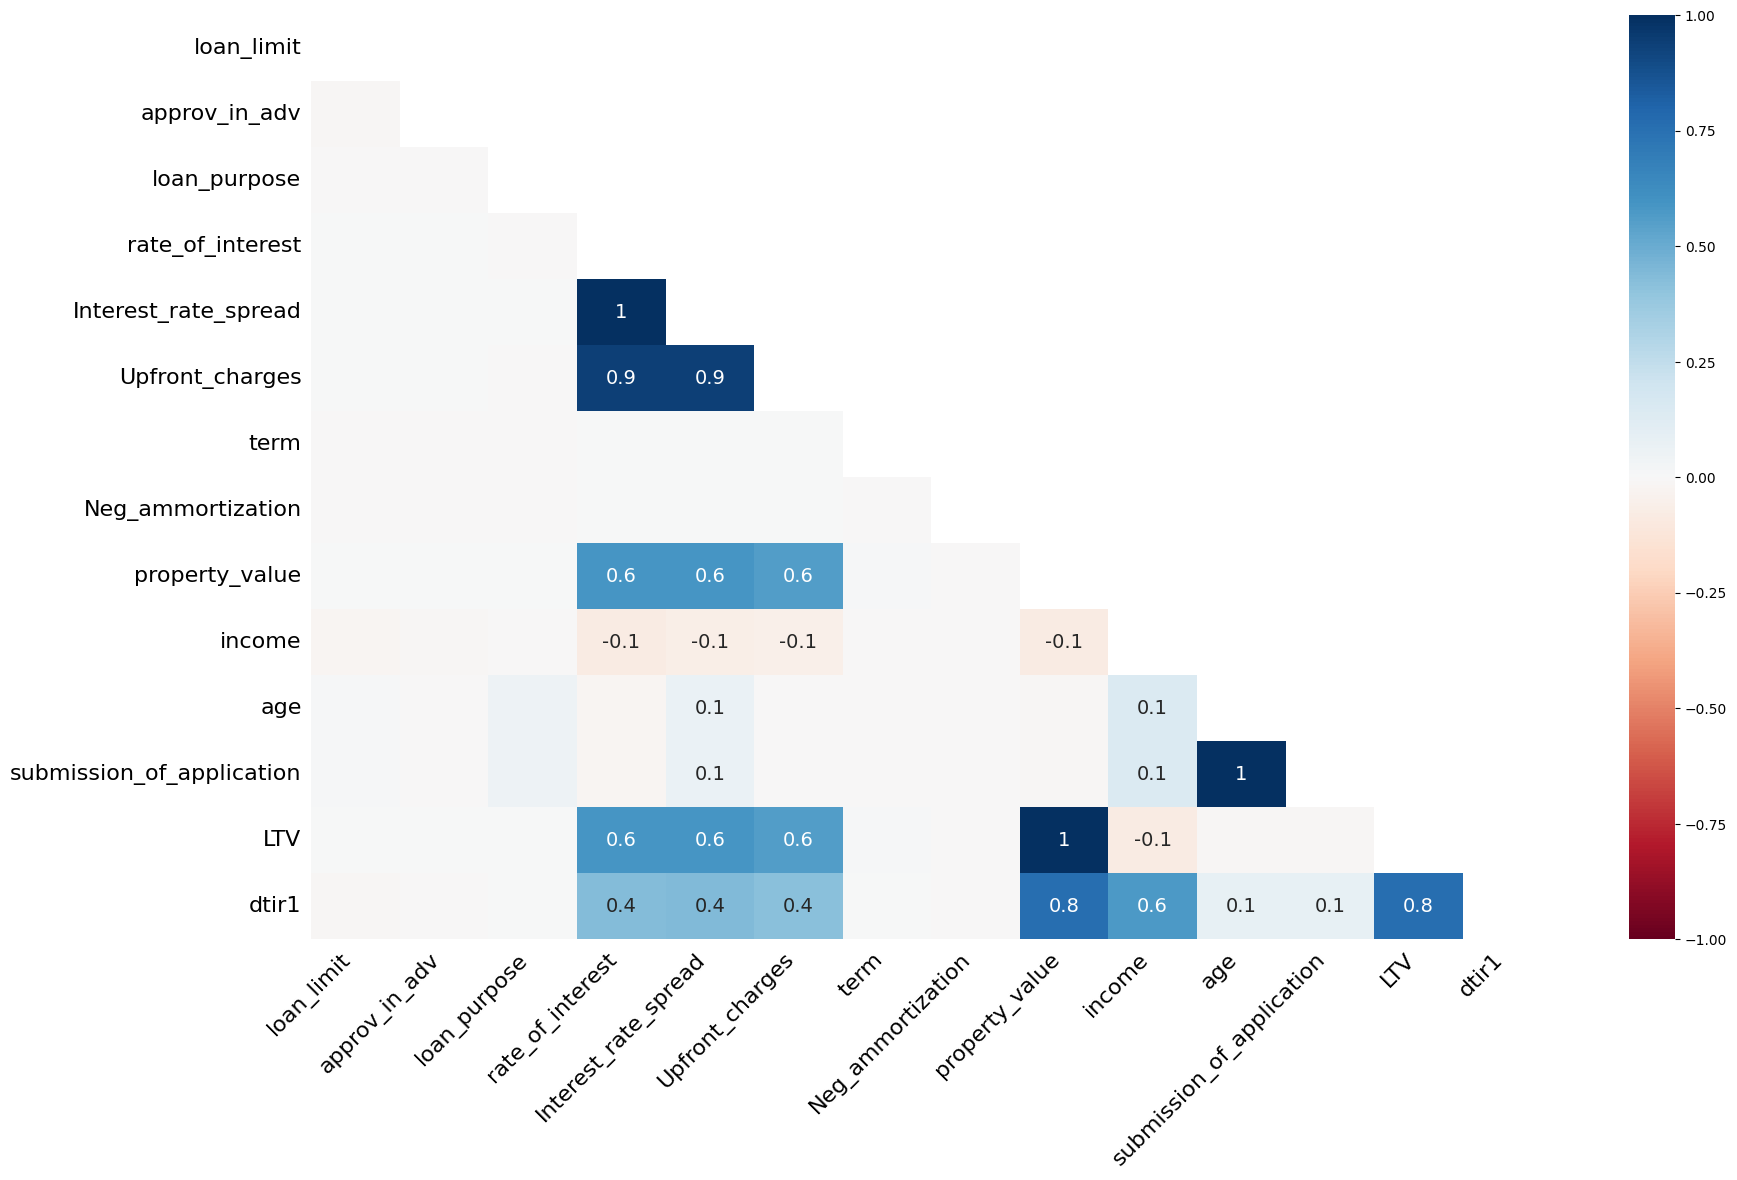

In [10]:
msno.heatmap(df, labels = True) # Используется коэффициент корреляции Пирсона, адаптированный для бинарных данных.(0, 1)


<style>
    table { font-size: 14px; } /* Уменьшаем шрифт */
</style>

#### Обзор возможных причин корреляции (выше 0,6) между пропусками в признаках 

| Переменная 1 | Переменная 2 | Значение | Вывод |
|------------|----------|------------|-------|
| age | submission_of_application  | 1 | Возможно, показывает, как люди заполняли анкеты |
| rate_of_interest | interest_rate_spread | 1 | Это производные метрики |
| rate_of_interest | Upfront_charges  | 0.9 | Возможно производные метрики
| interest_rate_spread | Upfront_charges  | 0.9 | Возможно производные метрики
| property_value | LTV | 1 | Это производные метрики |
| property_value | dtir1 | 0.8 |  Возможно, связь метрик объясняется через доход, <br> так как, наверное, в него включена стоимость недвижимости как актив |
| dtir1  | LTV | 0.8 | Возможно, связь метрик объясняется через доход, так как, <br> наверное, в него включена стоимость недвижимости как актив| | 


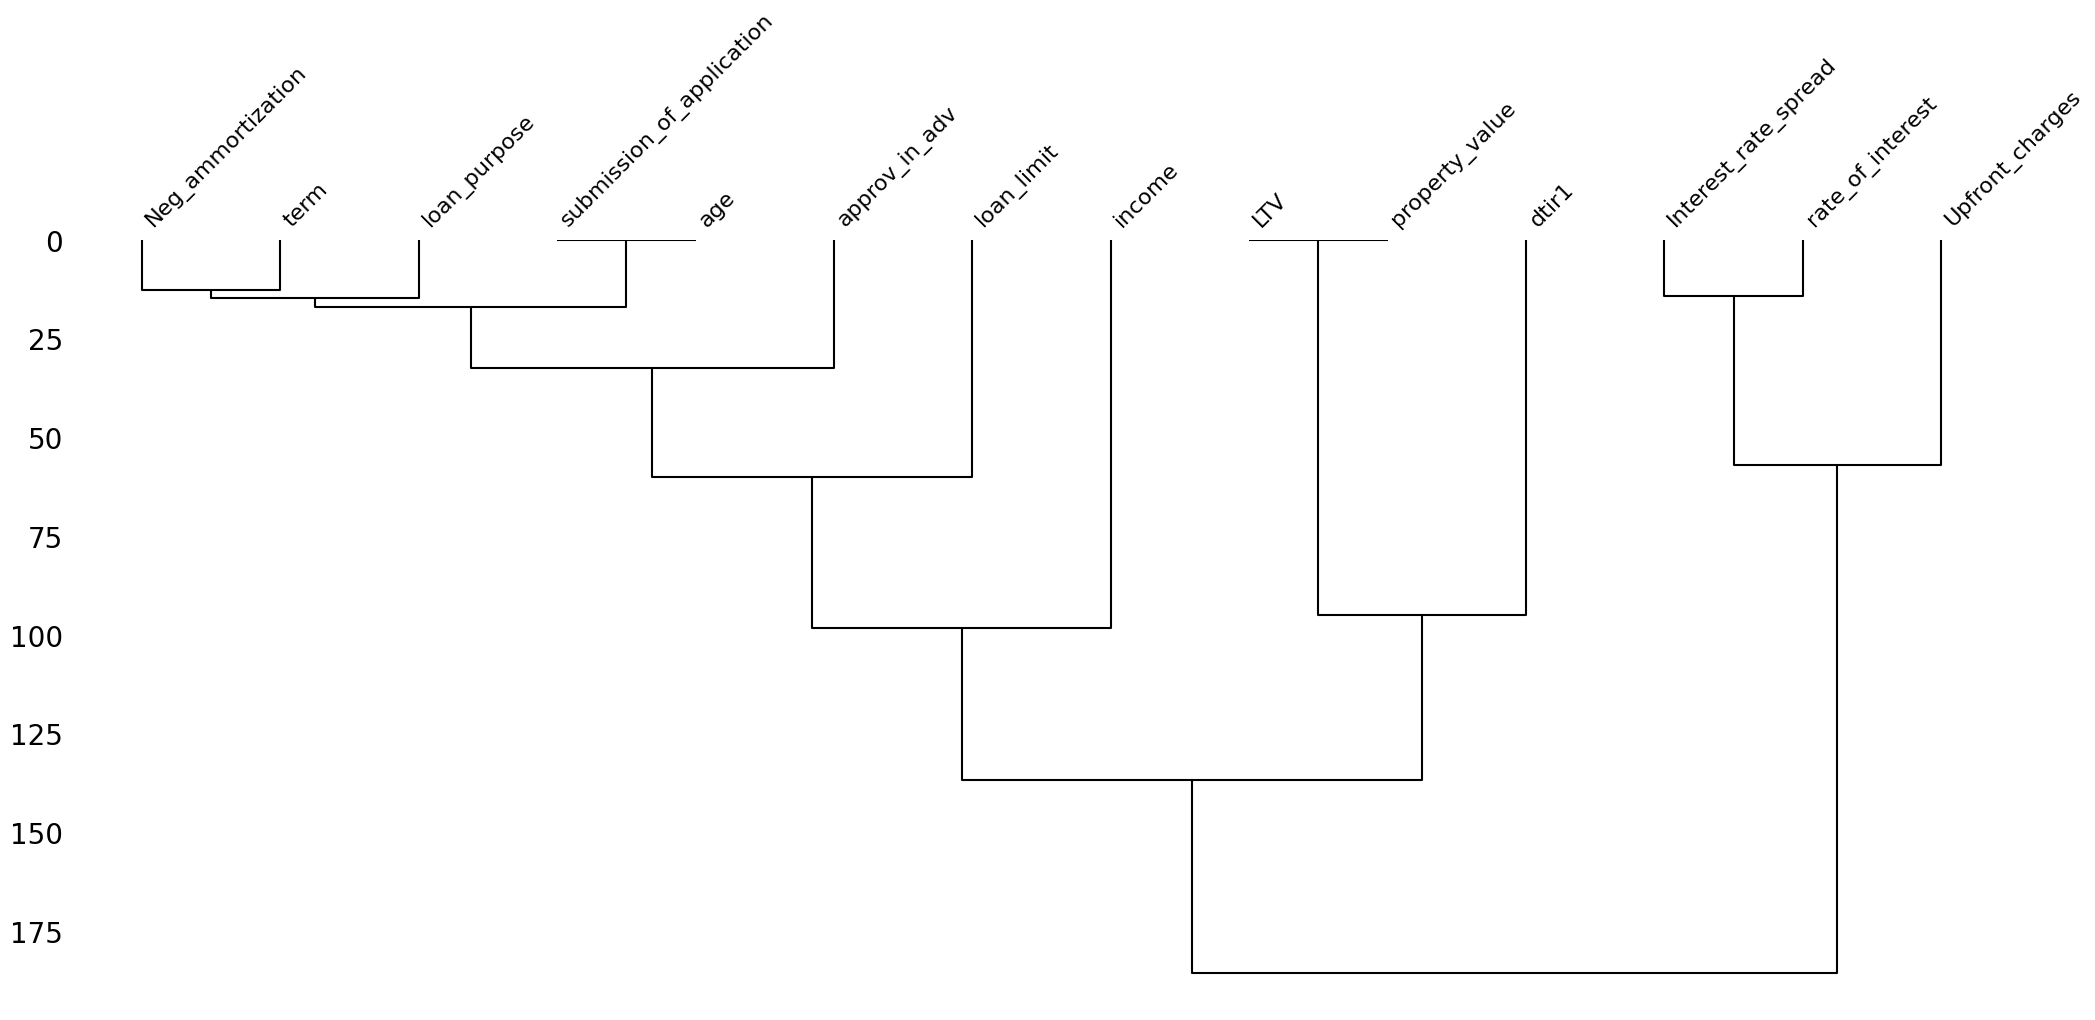

In [11]:
msno.dendrogram(df[missing_values[missing_values > 0].index.tolist()])

 #### Обзор характера пропусков между признаками

<small>
- Дендрограмма агрегированную меру различия паттернов пропусков, в условных единицах расстояния между столбцами, <br> производными кластерами на основе их паттернов пропущенных значений. <br>
- Значение близкое к 0 означает, что пропуски в двух столбцах происходят в одних и тех же строках (индексы совпадают). <br>
- Большое значение (дальше от 0) указывает на различия в расположении пропусков (индексы не совпадают). <br> 
- Видим, что пропуски в LTV совпадают с пропусками в property_value, а также в age и submissions. <br>
- А вот пропуски между кластером, связанным с rate_interest, и вторым кластером имеют наибольшее расхождение на ур. (175), <br>
но, возможно, это связано с тем, что пропусков у "ставок" больше всего. <br>
</small>

### 🧨 3. Обработка пропущенных значений

<style>
    table { font-size: 13px; } /* Уменьшаем шрифт */
</style>

#### Типы пропусков у переменных

- Случайные пропуски (MCAR — Missing Completely At Random)
- Пропуски, зависящие от других наблюдаемых переменных (MAR — Missing At Random)
- Пропуски, зависящие от самого значения или ненаблюдаемой переменной (MNAR — Missing Not At Random)

<br>

| Переменная                   | Пропущенные значения | Процент пропусков (%) | Тип пропуска            | Пояснение
|-----------------------------|----------------------|------------------------|---------------------|-----------------------|
| loan_limit                  | 3344                 | 2,25                   |    MNAR / MCAR  |Зависит от ненаблюдаемой переменной (или случайная)  |
| approv_in_adv              | 908                  | 0,61                   |   MNAR / MCAR       | Аналогично |
| loan_purpose               | 134                  | 0,09                   |   MNAR / MCAR      | Аналогично  |
| age                        | 200                  | 0,13                   | MNAR / MCAR | Аналогично | 
| submission_of_application | 200                  | 0,13                   |  MNAR / MCAR  | Аналогично |
| Neg_ammortization          | 121                  | 0,08                   | MNAR / MCAR| Аналогично |
| rate_of_interest           | 36439                | 24,51                  | MNAR    | Зависит от ненаблюдаемой переменной, но есть и корреляция с property_value |
| property_value             | 15098                | 10,16                  | MNAR    | Зависит от ненаблюдаемой переменной  |
| income                     | 9150                 | 6,15                   | MNAR  | Зависит от ненаблюдаемой переменной  |
| term                       | 41                   | 0,03                   | MCAR               | Случайный пропуск |
| LTV                        | 15098                | 10,16                  | MAR      | Производная переменная от property_value |
| dtir1                      | 24121                | 16,22                  | MAR          | Связанна с другими переменными income, property_value |
| Interest_rate_spread       | 36639                | 24,64                  | MAR   | Производная переменная от rate_of_interest |
| Upfront_charges            | 39642                | 26,66                  | MAR   | Взаимосвязанна с переменной rate_if_interest
 



Импутация пропусков (MNAR / MCAR)

In [12]:
# Индикаторы пропусков (категориальные) до импутации
df['loan_limit_missing'] = df['loan_limit'].isna().astype(int)
df['approv_in_adv_missing'] = df['approv_in_adv'].isna().astype(int)
df['loan_purpose_missing'] = df['loan_purpose'].isna().astype(int)
df['Neg_ammortization_missing'] = df['Neg_ammortization'].isna().astype(int)
df['submission_of_application_missing'] = df['submission_of_application'].isna().astype(int)
df['age_missing'] = df['age'].isna().astype(int)

# Индикаторы пропусков (числовые) до импутации
df['income_missing'] = df['income'].isna().astype(int)
df['property_value_missing'] = df['property_value'].isna().astype(int)
df['rate_of_interest_missing'] = df['rate_of_interest'].isna().astype(int)

# Категориальные переменные (MCAR / MNAR) с пропусками (импутируем модой)
cat_cols = ['loan_limit', 'approv_in_adv', 'loan_purpose', 'Neg_ammortization', 'submission_of_application', 'age']
# Числовые переменные (MCAR / MNAR) с пропусками (импутируем медианой)
num_cols = ['rate_of_interest', 'property_value', 'income', 'term']

from sklearn.impute import SimpleImputer
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])
print(df)


            ID  year loan_limit             Gender approv_in_adv loan_type  \
0        24890  2019         cf  Sex Not Available         nopre     type1   
1        24891  2019         cf               Male         nopre     type2   
2        24892  2019         cf               Male           pre     type1   
3        24893  2019         cf               Male         nopre     type1   
4        24894  2019         cf              Joint           pre     type1   
...        ...   ...        ...                ...           ...       ...   
148665  173555  2019         cf  Sex Not Available         nopre     type1   
148666  173556  2019         cf               Male         nopre     type1   
148667  173557  2019         cf               Male         nopre     type1   
148668  173558  2019         cf             Female         nopre     type1   
148669  173559  2019         cf             Female         nopre     type1   

       loan_purpose Credit_Worthiness open_credit business_or_c

<style>
    table { font-size: 15px; } /* Уменьшаем шрифт */
</style>

Импутация пропусков (MAR)

| Переменная          | Производная  | Комментарий                                           |
|--------------------------|--------------------------|------------------------------------------------------------|
| LTV                    | Да                 | Есть `loan_amount` и `property_value`                |
| dtir1            | Да                        | Очень важна для оценки риска                               |
| Upfront_charges        | Нет                        | Финансовый параметр, несёт смысл                           |
| interest_spread_rate   | Да                    | Если есть компоненты (напр., `rate_of_interest`)   |


In [13]:
%pip install missingpy
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

mask = ['LTV', 'dtir1', 'Upfront_charges', 'Interest_rate_spread']

imp = IterativeImputer(estimator=RandomForestRegressor(n_estimators=2, random_state=42), max_iter=2, random_state=42)
df[mask] = imp.fit_transform(df[mask])
print(df)


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
            ID  year loan_limit             Gender approv_in_adv loan_type  \
0        24890  2019         cf  Sex Not Available         nopre     type1   
1        24891  2019         cf               Male         nopre     type2   
2        24892  2019         cf               Male           pre     type1   
3        24893  2019         cf               Male         nopre     type1   
4        24894  2019         cf              Joint           pre     type1   
...        ...   ...        ...                ...           ...       ...   
148665  173555  2019         cf  Sex Not Available         nopre     type1   
148666  173556  2019         cf               Male         nopre     type1   
148667  173557  2019         cf               Male         nopre     type1   
148668  173558  2019         cf             Female         nopre     type1   
148669  173559  2019         cf             Female         nopre     type1  

d:\Python Language\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


####  Методы обработки пропусков 

<style>
    table { font-size: 15px; } /* Уменьшаем шрифт */
</style>

| Тип пропусков   | Тип данных   | Метод | Пояснение |
|-----|-----| ---------------------------| --------- |
| MAR   |  Числовые  | Случайный лес     | Не требует строгих предположений о данных |
| MAR   | Категориальные   |      -      | Таких данных нет
| MCAR   |  Числовые  |       Медиана    | Использую простой метод для случайных пропусков |
| MCAR  | Категориальные   |  Мода       | Использую простой метод для случайных пропусков  |
| MNAR   |  Числовые  |       Медиана + Индикаторы  | Использую дополнительно индикаторы  |
| MNAR  | Категориальные   |  Мода   + Индикаторы    | Использую дополнительно индикаторы |

<br>
<small>
Пояснение к выбору модели случайного леса

Случайный лес не требует строгих предположений о распределении данных. Ему не нужна нормальность признаков, он устойчив к различным масштабам и слабо чувствителен к мультиколлинеарности. Также нет необходимости проверять автокорреляцию, гомоскедастичность и другие статистические свойства, требуемые в линейных моделях.
</small>

### ⚡ 4. Анализ выбросов

#### Поиск категориальных выбросов. Частотный анализ

Визуализация. Возьмем только категориальные признаки.

C:\Users\blue\AppData\Local\Temp\ipykernel_10608\1246559616.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y=col, data=counts, ax=ax, palette="Set2")
C:\Users\blue\AppData\Local\Temp\ipykernel_10608\1246559616.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y=col, data=counts, ax=ax, palette="Set2")
C:\Users\blue\AppData\Local\Temp\ipykernel_10608\1246559616.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y=col, data=counts, ax=ax, palette="Set2")
C:\Users\blue\AppData\Local\Temp\ipykernel_106

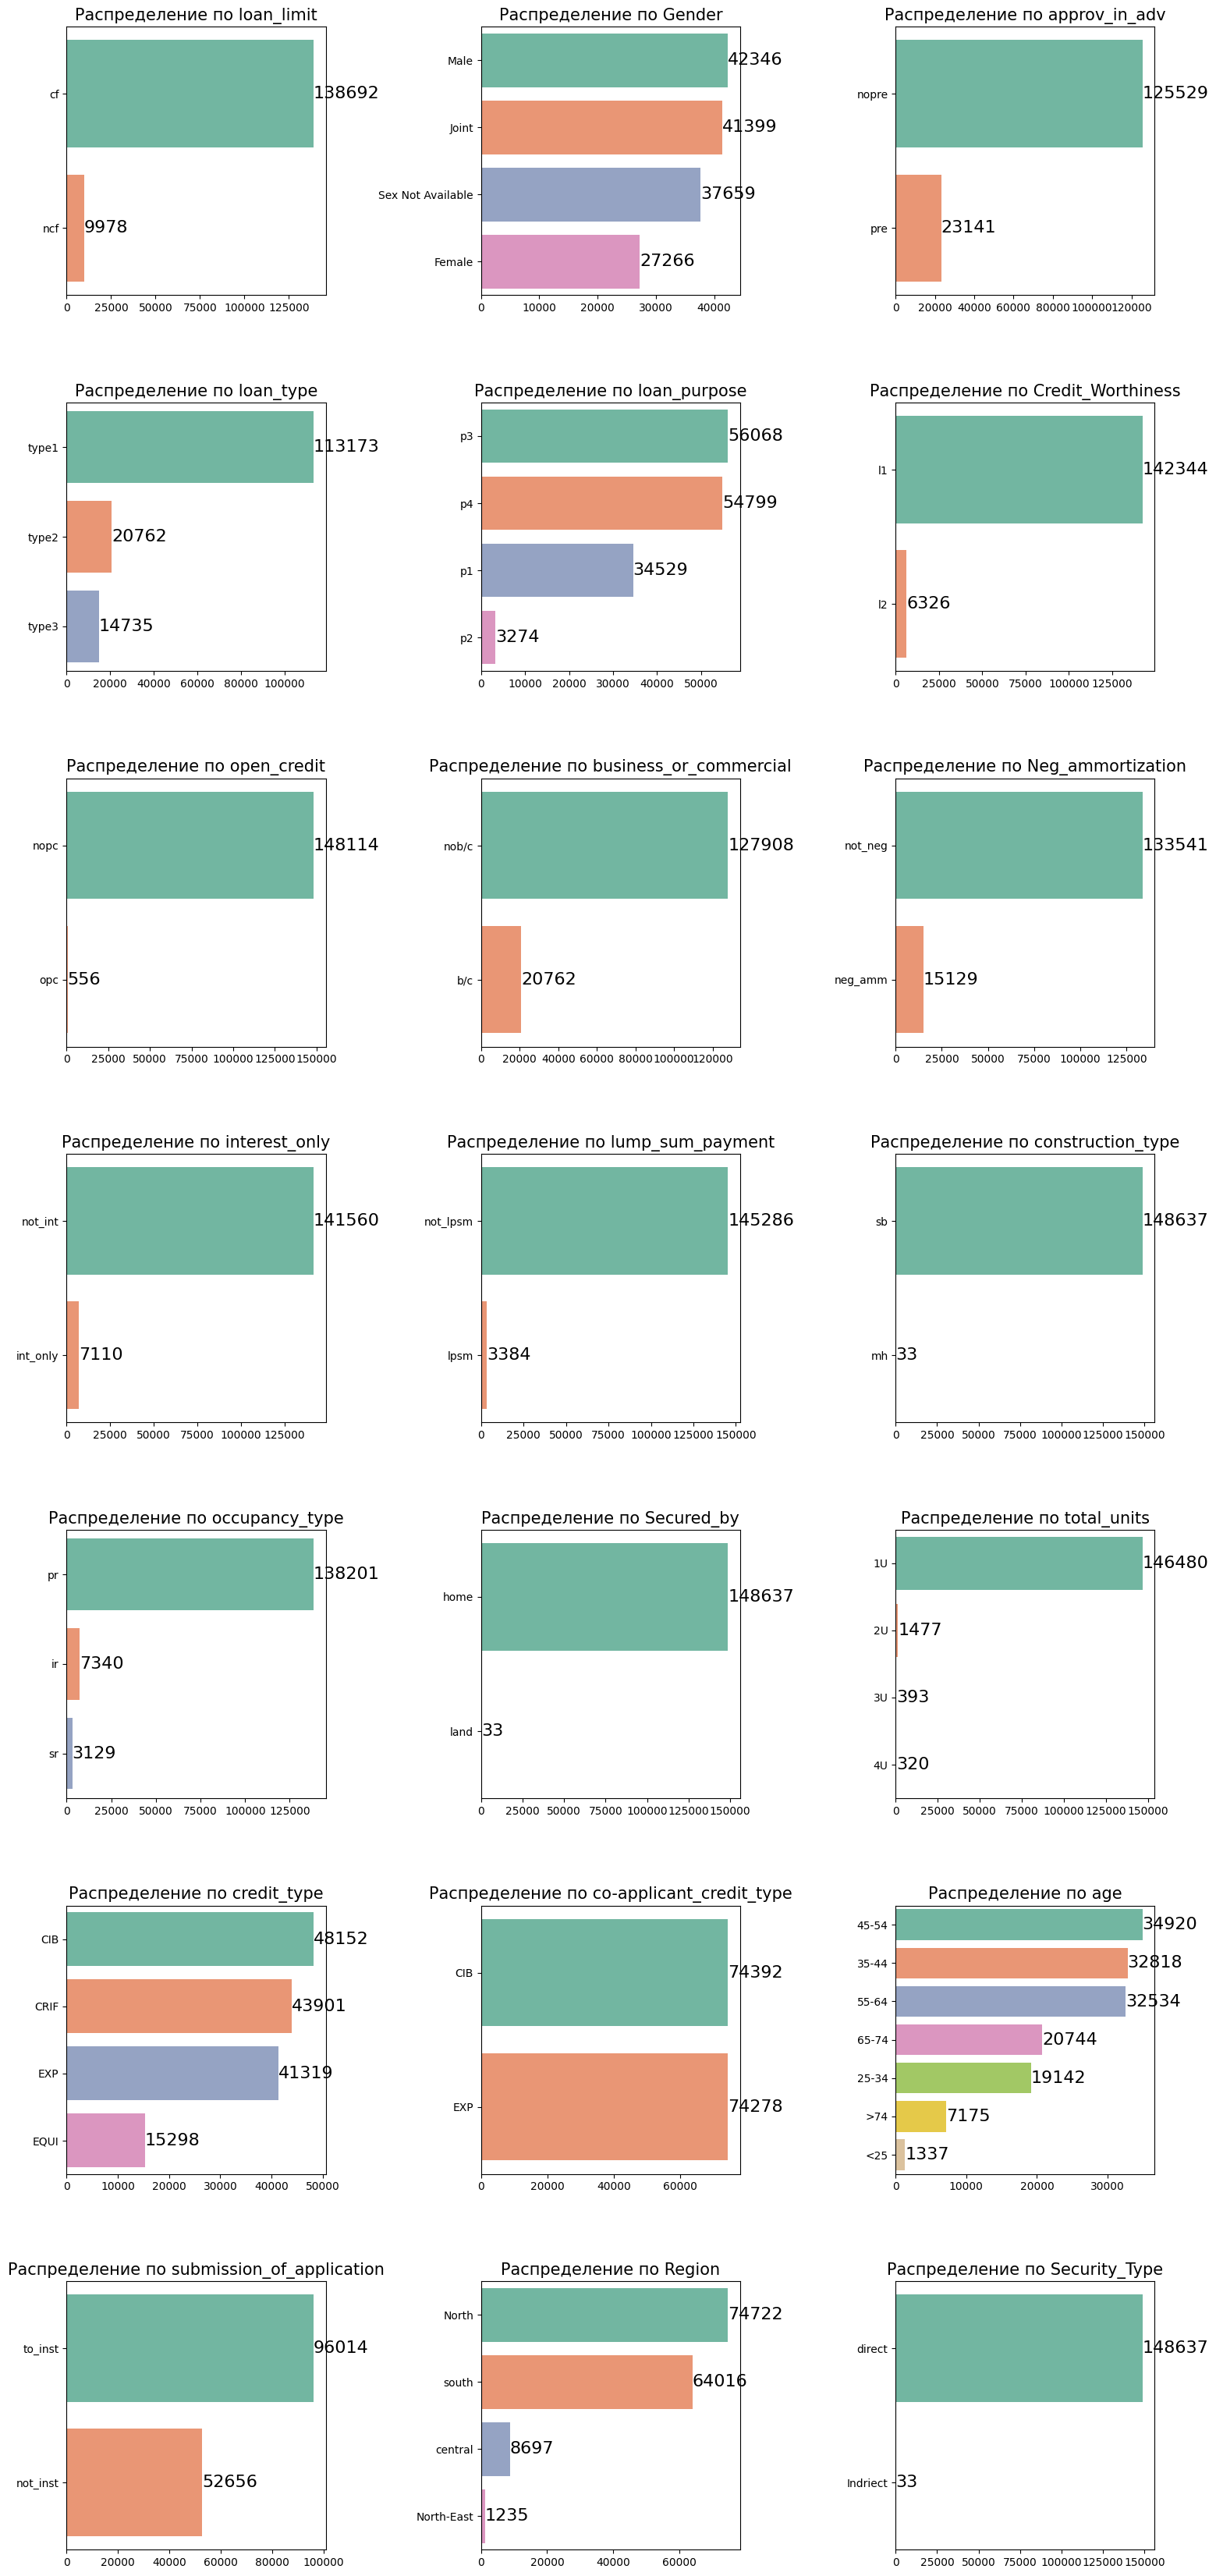

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cat_cols = df.select_dtypes(include='object').columns.tolist()

num_columns = len(cat_cols)
n_rows = int(np.ceil(num_columns / 3))
n_cols = min(num_columns, 3)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    counts = df[col].value_counts().reset_index()
    counts.columns = [col, 'count']

    sns.barplot(x='count', y=col, data=counts, ax=ax, palette="Set2")

    for p in ax.patches:
        ax.text(p.get_width() + 0.5, p.get_y() + p.get_height() / 2,
                f'{p.get_width():.0f}', va='center', ha='left', fontsize=16)

    ax.set_title(f"Распределение по {col}", fontsize=15)
    ax.set_xlabel("", fontsize=16)
    ax.set_ylabel("", fontsize=16)

for i in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[i])

plt.subplots_adjust(hspace=0.4, wspace=0.6)
plt.show()

Частотный анализ. 
Поставим порог в 1% для нахождения выбросов по частотам. <br> 
Получим выбросы и посмотрим на качество данных. Дополнительно посмотрим ещё раз на частоты индикаторов.

In [15]:
category_percent_dict = {}
outliers_dict = {}
threshold = 1

indicators = ['rate_of_interest_missing', 'property_value_missing', 'income_missing', 'loan_limit_missing',
  'approv_in_adv_missing', 'loan_purpose_missing', 'Neg_ammortization_missing', 'submission_of_application_missing', 'age_missing']

frequency_array = cat_cols + indicators

for col in frequency_array:
    category_percent = df[col].value_counts(normalize=True) * 100
    category_percent = category_percent.round(2)

    category_percent_list = [(index, percent) for index, percent in category_percent.items()]
    category_percent_dict[col] = category_percent_list

    outliers = []
    for index, percent in category_percent.items():
        if percent < threshold:
            outliers.append((index, percent))
            print(f"Выброс в {col}: {index} - {percent:.2f}%")

    if outliers:
        outliers_dict[col] = outliers

Выброс в open_credit: opc - 0.37%
Выброс в construction_type: mh - 0.02%
Выброс в Secured_by: land - 0.02%
Выброс в total_units: 2U - 0.99%
Выброс в total_units: 3U - 0.26%
Выброс в total_units: 4U - 0.22%
Выброс в age: <25 - 0.90%
Выброс в Region: North-East - 0.83%
Выброс в Security_Type: Indriect - 0.02%
Выброс в approv_in_adv_missing: 1 - 0.61%
Выброс в loan_purpose_missing: 1 - 0.09%
Выброс в Neg_ammortization_missing: 1 - 0.08%
Выброс в submission_of_application_missing: 1 - 0.13%
Выброс в age_missing: 1 - 0.13%


#### Природа категориальных выбросов и пропусков

<style>
    table { font-size: 14px; } /* Уменьшаем шрифт */
</style>

Таблица с категориальными признаками


| Столбец            | Категория | Процент (%) | Гипотезы природы выбросов |
|--------------------|-----------|-------------|-----------------|
| open_credit      | opc       | 0.37        | Людям с открытыми кредитами сложнее получить одобрение на новый кредит |
| construction_type | mh        | 0.02        | Мобильные дома встречаются реже, чем капитальные здания |
| Secured_by       | land      | 0.02        | Земля как залог — редкий тип залога для большинства кредитов |
| total_units      | 2U        | 0.99        | Чем больше единиц финансируемой недвижимости, тем, вероятно, заемщик обладает большими финансовыми <br> возможностями, так как объекты недвижимости обычно дорогие, но таких заемщиков мало |
| total_units     | 3U        | 0.26        | Аналогично |
| total_units    | 4U        | 0.22        | Аналогично |
| Region          | North-East      | 0.83  | Допустим очень дорогие квартиры в этом районе
| Security_Type   | Indriect      | 0.02  |  Думаю банки просто реже одобряют такие кредиты
| age             | <25       | 0.90        | Людям младше 25 редко одобряют кредиты или они реже их берут, предполагаю из-за проблем с финансами |

<br>

Таблица с индикаторами

| Столбец                            | Категория | Процент (%) | Природа пропусков |
|------------------------------------|-----------|-------------|---------------------------| 
| approv_in_adv_missing              | Пропуск |    0.61         | Трудно сказать |               
| loan_purpose_missing               | Пропуск |    0.09         | Все же ближе к MCAR, чем MNAR | 
| Neg_ammortization_missing          | Пропуск |    0.08         | Все же ближе к MCAR, чем MNAR | 
| submission_of_application_missing  | Пропуск |    0.13         | Все же ближе к MCAR, чем MNAR | 
| age_missing                        | Пропуск |    0.13         | Все же ближе к MCAR, чем MNAR | 


#### Поиск числовых выбросов
Далее проведем анализ только 13 числовых признаков. <br>

In [16]:
import scipy.stats as stats

digit_columns = df.select_dtypes(include=['int64', 'float64']).columns.drop(indicators)
df_digit = df[digit_columns]
df_digit_corr = df_digit.copy()
print(df_digit.shape[1])


13


Визуализация числовых выбросов через boxplot

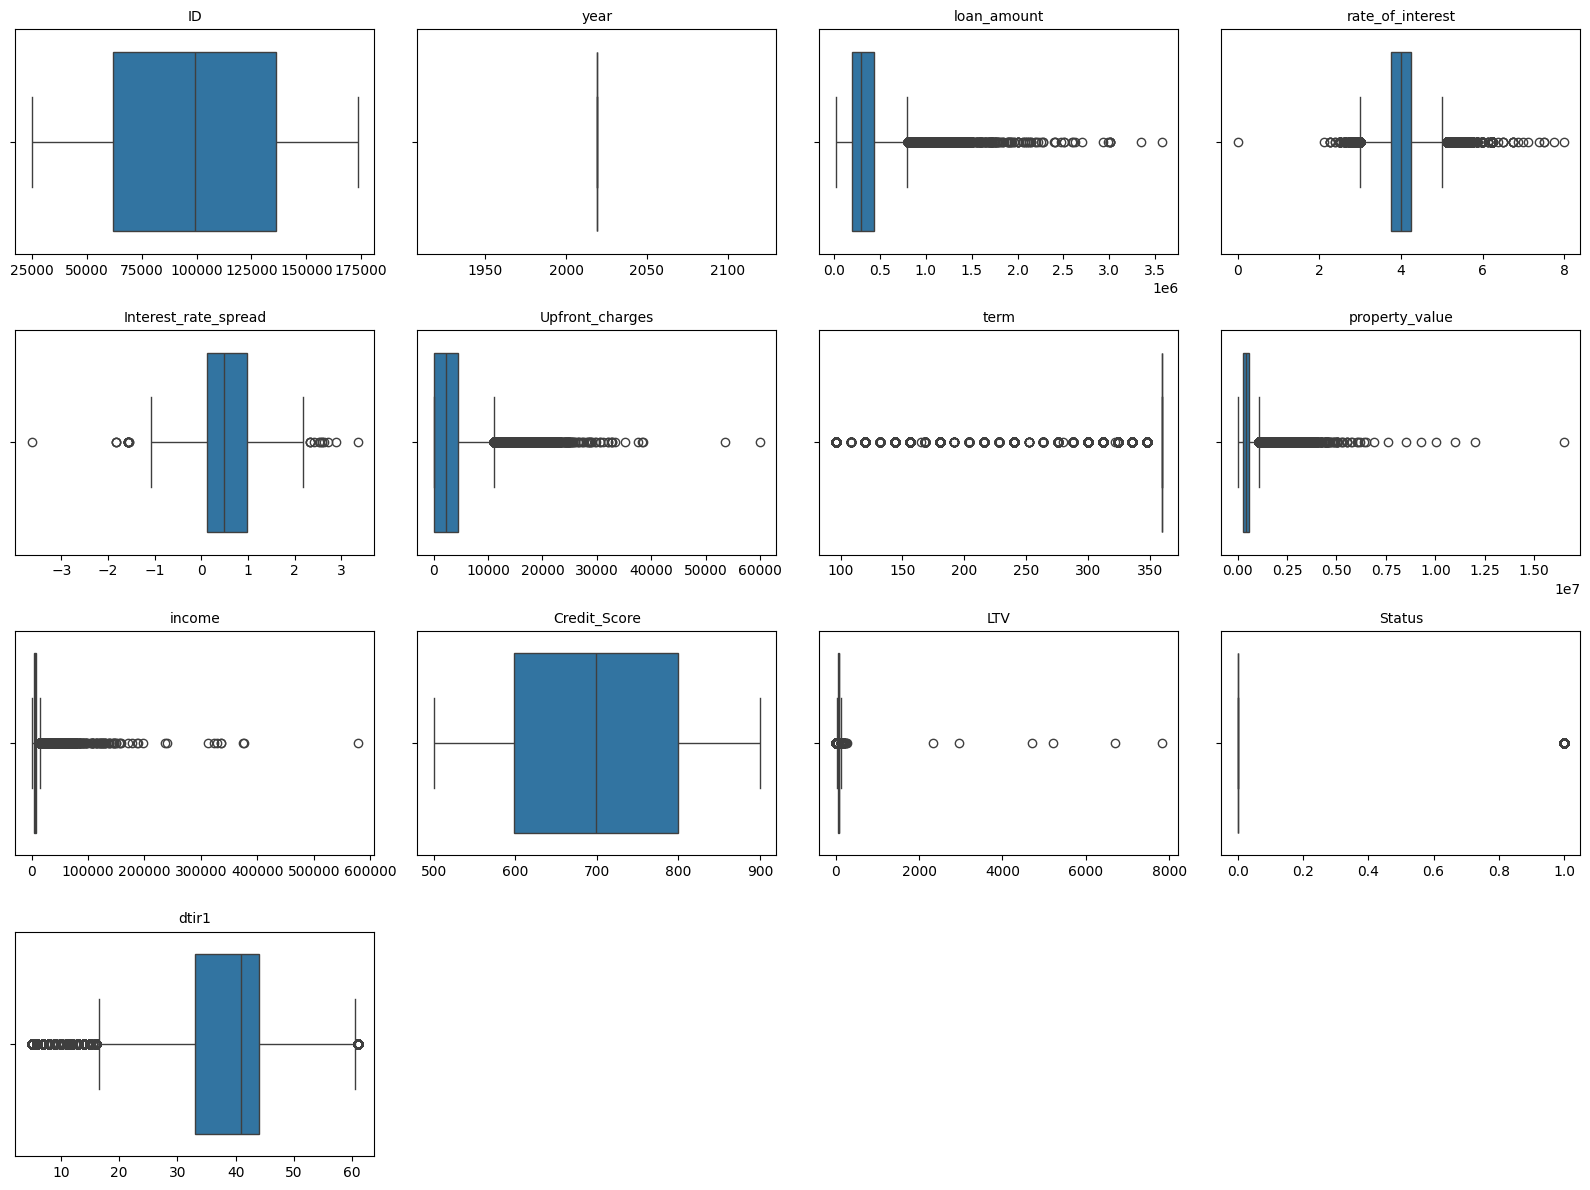

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

num_columns = len(digit_columns)
num_rows = int(np.ceil(num_columns / 4))
num_cols = min(num_columns, 4)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows * 3))
axes = axes.flatten()

for i, col in enumerate(digit_columns):
    sns.boxplot(x=df_digit[col].dropna(), ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Проблемные переменные: year, Status, term, income, LTV, ID

Не трогаем `ID` и целевую переменную `Status` (она полностью дискретная), так как в них нет смысла удалять или менять выбросы. <br>
Также дополнительно я счел ненужным трогать `year`. Забегая вперед, скажу, что год везде один.

In [18]:
print(df_digit['year'].unique()) # type: ignore

[2019]


<small>
Избавься от них на месте — в этой копии датасета, чтобы они не мешали при анализе выбросов. В основном df они пока остаются
</small>

In [19]:
df_digit = df_digit.drop(columns=['ID', 'Status', 'year'])

Поиск числовых выбросов IQR, используем стандартное значение 1.5 (и 3) поочередно

In [20]:
import numpy as np

outliers_iqr = pd.DataFrame()
outliers_count_iqr = {}

for col in df_digit.columns:

        Q1 = df_digit[col].quantile(0.25)
        Q3 = df_digit[col].quantile(0.75)

        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        column_outliers = df_digit[(df_digit[col] < lower_bound) | (df_digit[col] > upper_bound)]

        if not column_outliers.empty:
            outliers_count_iqr[col] = column_outliers.shape[0]
            outliers_iqr = pd.concat([outliers_iqr, column_outliers])

outliers_iqr = outliers_iqr.drop_duplicates() # Если одна и та же строка яв. выбросом несколько раз.


print(f"Общее количество уникальных строк с выбросами: {outliers_iqr.shape[0]}")
print("\nКоличество выбросов по столбцам:")
for col, count in outliers_count_iqr.items():
    print(f"{col}: {count}")

Общее количество уникальных строк с выбросами: 47548

Количество выбросов по столбцам:
loan_amount: 1895
rate_of_interest: 6817
Interest_rate_spread: 26
Upfront_charges: 3209
term: 26944
property_value: 6596
income: 7636
LTV: 1939
dtir1: 5570


График кол-во числовых выбросов IQR 1.5 / 3

C:\Users\blue\AppData\Local\Temp\ipykernel_10608\3703342040.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Column', y='Outliers', data=df_outliers_iqr, palette='magma')


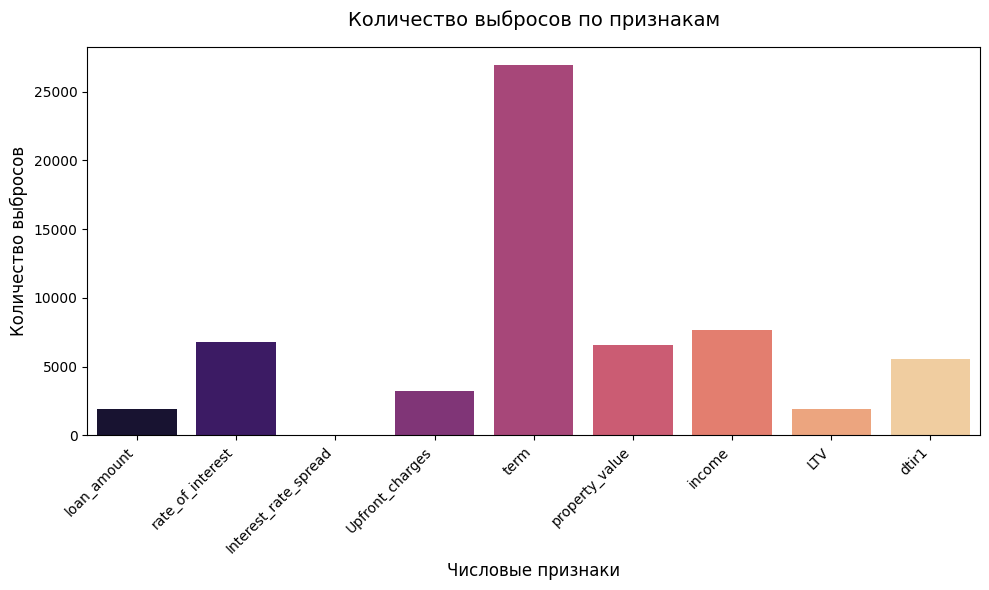

In [21]:
df_outliers_iqr = pd.DataFrame(list(outliers_count_iqr.items()), columns=['Column', 'Outliers'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Column', y='Outliers', data=df_outliers_iqr, palette='magma')
plt.xticks(rotation=45, ha='right')
plt.title("Количество выбросов по признакам", fontsize=14, pad=15)
plt.xlabel("Числовые признаки", fontsize=12)
plt.ylabel("Количество выбросов", fontsize=12)
plt.tight_layout()
plt.show()

Пробуем ещё один унивариативный метод Z-score. Значения с |Z-score| > 3 считаются выбросами по правилу "трёх сигм" <br>
Использовать Z-score без нормализации данных — можно, но надо быть осторожным с интерпретацией

In [22]:
import pandas as pd

def z_score_outliers(df, threshold=3):

    outliers_count_z = {}
    outliers_z = pd.DataFrame()
    num_cols = df

    for col in num_cols:
        zs = (df[col] - df[col].mean()) / df[col].std()
        mask = zs.abs() > threshold # Значения с |Z-score| > 3 считаются выбросами по правилу "трёх сигм".

        column_outliers = df[mask]
        if not column_outliers.empty:
            outliers_count_z[col] = column_outliers.shape[0]
            outliers_z = pd.concat([outliers_z, column_outliers], axis=0)

    outliers_z = outliers_z.drop_duplicates()

    print(f"Общее количество уникальных строк с выбросами: {outliers_z.shape[0]}")
    print("\nКоличество выбросов по столбцам:")
    for col, cnt in outliers_count_z.items():
        print(f"{col}: {cnt}")

    return outliers_z

outliers_z = z_score_outliers(df_digit)

Общее количество уникальных строк с выбросами: 10033

Количество выбросов по столбцам:
loan_amount: 1371
rate_of_interest: 1400
Interest_rate_spread: 26
Upfront_charges: 2200
term: 1267
property_value: 2291
income: 1532
LTV: 17
dtir1: 1625


Пробую KNN из пакета pyod (Мультивариативный поиск)

In [23]:
%pip install pyod
from pyod.models.knn import KNN
outliers_knn = df_digit.copy()

clf = KNN()
clf.fit(outliers_knn)
outliers_knn['outlier'] = clf.predict(outliers_knn)  # 1 — выброс, 0 — нормально

print(outliers_knn.shape[0])
outliers_knn['outlier'] = outliers_knn['outlier'].astype(int)
print(outliers_knn['outlier'].value_counts())

outliers_only = outliers_knn[outliers_knn['outlier'] == 1]
print(f"Количество выбросов: {outliers_only.shape[0]}")


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
148670
outlier
0    135568
1     13102
Name: count, dtype: int64
Количество выбросов: 13102


#### Природа и количество числовых выбросов 

<small>
Числа здесь приблизительные — они могут немного меняться в зависимости от выбранных параметров при импутации пропусков через модель
</small>

<br>

<style>
    table { font-size: 14px; } /* Уменьшаем шрифт */
</style>
<br>

| Столбец                | IQR 1.5 | IQR 3  | Z-score 3  | KNN  | Гипотезы природы выбросов |
|------------------------|------------|---------------- |---------------|------|----------------------------|
| loan_amount            |   1895  |    440 |      1371 |      | У обеспеченных — крупные кредиты, <br> у малообеспеченных — очень маленькие суммы |
| rate_of_interest       |   6817  |    351 |      1400 |      | Льготные или, наоборот, завышенные процентные ставки |
| Interest_rate_spread   |     26  |      2 |        26 |      | Производная от rate_of_interest — зависит от неё напрямую |
| Upfront_charges        |   3209  |   1161 |      2200 |      | Возможны ошибки ввода или крайние случаи с высокими/нулевыми комиссиями |
| term                   |  26944  |  26944 |      1267 |      | Низкая вариативность значений — возможно, <br> это категориальная переменная, замаскированная под числовую |
| property_value         |   6596  |   2204 |      2291 |      | Очень высокая или заниженная стоимость недвижимости |
| income                 |   7636  |   2461 |      1532 |      | Крайние значения — очень высокие или низкие доходы |
| LTV                    |   1939  |     43 |        17 |      | Производная от property_value и loan_amount |
| dtir1                  |   5570  |     -  |      1625 |      | Либо слишком низкая нагрузка (высокий доход), <br> либо очень высокая (низкий доход и большой кредит) |
| Всего уникальных строк с выбросами | 47548 | 31562 | 10033 | 13102 | — |







#### График выбросов Z-score через Violin Plot

C:\Users\blue\AppData\Local\Temp\ipykernel_10608\3654794963.py:9: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=outliers_normalized,


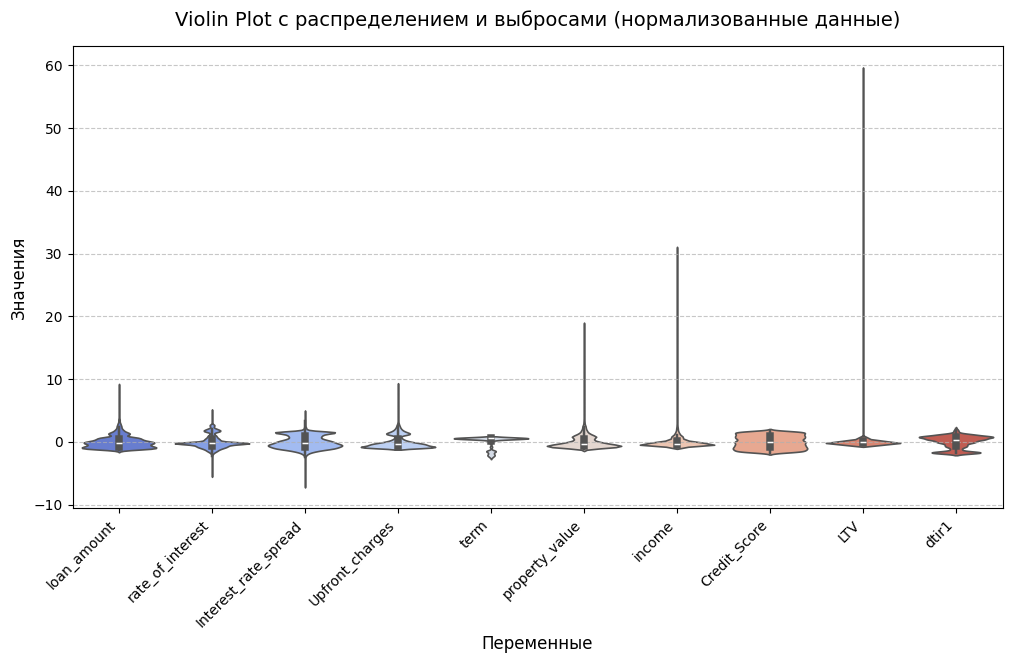

In [24]:
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

scaler = StandardScaler()
outliers_normalized = pd.DataFrame(scaler.fit_transform(outliers_z), columns=outliers_z.columns)

plt.figure(figsize=(12, 6))
sns.violinplot(data=outliers_normalized,
               palette="coolwarm",
               inner="box",
               scale="width",
               linewidth=1.2)

plt.xticks(rotation=45, ha='right')
plt.title("Violin Plot с распределением и выбросами (нормализованные данные)", fontsize=14, pad=15)
plt.xlabel("Переменные", fontsize=12)
plt.ylabel("Значения", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<small>
До использования Z-score, KNN: <br>

Видим наибольшее количество выбросов в признаке term (срок кредита), далее следуют показатели income (доход) и property_value <br>
Полагаю, что с term, как я писал ранее, не всё так просто, и стоит попробовать другие методы для определения выбросов

После: 

Получили удовлетворительный результат как по KNN, так и по Z-score. <br> В принципе, будем использовать Z-score, так как он справляется с дискретностью в переменной term
</small>

### 🎰 5. Обработка категориальных данных

Выводим количество уникальных значений для каждого категориального признака


In [25]:
cat_cols = df.select_dtypes(include='object').columns
unique_counts = df[cat_cols].nunique().sort_values()
unique_counts.columns = ['Кол-во уникальных значений']
print(unique_counts)

loan_limit                   2
approv_in_adv                2
open_credit                  2
Credit_Worthiness            2
business_or_commercial       2
lump_sum_payment             2
interest_only                2
Neg_ammortization            2
Secured_by                   2
construction_type            2
submission_of_application    2
co-applicant_credit_type     2
Security_Type                2
loan_type                    3
occupancy_type               3
loan_purpose                 4
credit_type                  4
total_units                  4
Gender                       4
Region                       4
age                          7
dtype: int64



<style>
    table { font-size: 13px; } /* Уменьшаем шрифт */
</style>

<small>
Провожу небольшое деление бинарных значений, но оно не повлияет в дальнейшем <br>

🔹 Бинарные категории "да/нет" — логические, можно интерпретировать как истину/ложь <br>
🔹 Просто две категории без смысла "да/нет" — номинативные, порядок и логика отсутствуют.


#### 👟 Бинарные переменные. Использую Label Encoding


| Переменная            | Описание                                      | Пояснение | Тип |
|-----------------------|-----------------------------------------------|---------- | ------- |
| open_credit           | Есть ли открытые кредиты                      | Есть / Нет | Логические |
| Neg_ammortization     | Отрицательная амортизация                     | Есть / Нет | Логические |
| loan_limit            | Ограничение по кредиту                        | Соотвествует требованиям / <br> не соответствует | Логические |
| approv_in_adv         | Одобрен ли кредит заранее                     | Да / Нет | Логические |
| interest_only         | Только процентные выплаты                     | Есть / Нет | Логические |
| lump_sum_payment      | Единовременный платёж в конце                 | Есть / Нет | Логические | 
| submission_of_application | Способ подачи заявки                      | В банке / Не в банке | Логические |
| construction_type         | Тип постройки                             | Капитальная / <br> Мобильный дом |  Не логические
| Secured_by                | Тип залога                                | Дом / Земля | Не логические
| Security_Type             | Тип обеспечения                           | Прямой / косвенный | Не логические
| business_or_commercial    | Назначение кредита                        | Для бизнеса / личный | Не логические
| co-applicant_credit_type  | Тип кредитной информации созаемщика       | CIB / EXP | Не логические



#### 👕Номинальные переменные. Использую One-Hot Encoding (Не так много уникальных значений)
| Переменная                  | Описание                              | Количество | 
|----------------------------|----------------------------------------| ---------- | 
| Gender                     | Пол заявителя ( > 2)                   | 4 | 
| credit_type                | Тип кредитной информации заявителя     | 4 |
| Region                    | Регион недвижимости                     | 4 | 
| loan_purpose              | Цель кредита                            | 4 | 
| loan_type                 | Тип кредита                             | 3 | 
| occupancy_type            | Тип использования недвижимости          | 3 | 


#### 🎃Порядковые переменные. Использую Label Encoding
| Переменная        | Описание                                                     | Количество |
|-------------------|--------------------------------------------------------------|------------
| Credit_Worthiness | Кредитоспособность (l1, l2)                                  | 2 |
| total_units       | Кол-во единиц недвижимости                                   | 4 |
| age | Возрастные диапазоны| 7 |

Переменная total_units впоследствии будет преобразована в бинарный формат.
</small>
<br>

Преобразование бинарных и порядковых переменных

In [26]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
label_encoder = LabelEncoder()

# Преобразование бинарных переменных
binary_cols = [
    'open_credit', 'Neg_ammortization', 'loan_limit',
    'approv_in_adv', 'interest_only', 'lump_sum_payment',
    'submission_of_application', 'construction_type',
    'Secured_by', 'Security_Type', 'business_or_commercial',
    'co-applicant_credit_type']

for col in binary_cols:
    df[col] = label_encoder.fit_transform(df[col])


# Преобразование переменных с порядком
order_cols = {'Credit_Worthiness': ['l1', 'l2'], 'age': ['<25', '25-34', '35-44', '45-54', '55-64', '65-74', '>74'],
               'total_units': ['1U', '2U', '3U', '4U']}

for col in order_cols:
    df[col] = OrdinalEncoder(categories=[order_cols[col]]).fit_transform(df[[col]])

Преобразование номинальных переменных

In [27]:
import pandas as pd
# Преобразование номинальных переменных
cat_cols = ['Gender', 'credit_type', 'Region', 'loan_purpose', 'loan_type', 'occupancy_type']
# Применяем One-Hot Encoding и удаляем первый столбец каждой категории
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(df)

            ID  year  loan_limit  approv_in_adv  Credit_Worthiness  \
0        24890  2019           0              0                0.0   
1        24891  2019           0              0                0.0   
2        24892  2019           0              1                0.0   
3        24893  2019           0              0                0.0   
4        24894  2019           0              1                0.0   
...        ...   ...         ...            ...                ...   
148665  173555  2019           0              0                0.0   
148666  173556  2019           0              0                0.0   
148667  173557  2019           0              0                0.0   
148668  173558  2019           0              0                0.0   
148669  173559  2019           0              0                0.0   

        open_credit  business_or_commercial  loan_amount  rate_of_interest  \
0                 0                       1       116500             3.990   
1  

### 🌍 6. Обработка выбросов

#### Решение для категориальных выбросов

<style>
    table { font-size: 14px; } /* Уменьшаем шрифт */
</style>

| Столбец            | Категория | Частота (%) | Решение          | Обоснование |
|--------------------|-----------|--------------|-------------------------|--------------|
| open_credit      | opc     | 0.37         | ✔️ Оставить             | Семантически осмысленная категория, может влиять на дефолт по кредиту |
| construction_type | mh      | 0.02         | 🧨 Удалить бинарный столбец   | Очень редкая, может создать шум или переобучение |
| Secured_by       | land    | 0.02         | 🧨 Удалить бинарный столбец  | Очень редкая,  может создать шум или переобучение |
| total_units      | 2U      | 0.99         | 🔄 Объединить в multi_unit | Логически близка к `3U`, `4U`; вместе формируют значимую группу |
| total_units      | 3U     | 0.26         |  🔄 Объединить в multi_unit | Аналогично |
| total_units      | 4U     | 0.22         |  🔄 Объединить в multi_unit | Аналогично |
| age              | <25     | 0.90         | ✔️Оставить             | Осмысленная категория |
| Region          | North-East      | 0.83  | ✔️Оставить   | Осмысленная категория |
| Security_Type   | Indriect      | 0.02  | 🧨 Удалить бинарный столбец | Очень редкая,  может создать шум или переобучение |4


<br>

Решения для индикаторов 
| Столбец            | Категория | Частота (%) |    Решение
|--------------------|-----------|--------------|-------------------------|
| approv_in_adv_missing              | Пропуск |    0.61         |  ✔️ Оставим столбец |                 
| loan_purpose_missing               | Пропуск |    0.09         |  🧨 Можно удалить |
| Neg_ammortization_missing          | Пропуск |    0.08         |  🧨 Можно удалить |
| submission_of_application_missing  | Пропуск |    0.13         |  🧨 Можно удалить |
| age_missing                        | Пропуск |    0.13         |  🧨 Можно удалить |

<small> <br>
Удалять будем в самом конце перед обучением
</small>


Объединяем U2, U3 и U4 в значение 0, а 1U — в значение 1. Преобразуем total_units в бинарную переменную.

In [28]:
mask = [2, 3, 4]
df['total_units'] = df['total_units'].apply(lambda x: 0 if x in mask else 1)

#### Решение для числовых выбросов

<style>
    table { font-size: 14px; } /* Уменьшаем шрифт */
</style>

Возможно следует удалить следующие переменные:
<br>

| Переменная          | Производная от других | Удалять? | Комментарий                                           |
|--------------------------|------------------|---------------|------------------------------------------------------------|
| LTV                    | Да               | 🔔 См. далее результаты корреляции     | Есть loan_amount и property_value                |
| dtir1            | Да               | ✔️ Нет           | Очень важна для оценки риска                               |
| Upfront_charges        | Нет              | ✔️ Нет           | Финансовый параметр, несёт смысл                           |
| interest_spread_rate   | Да               |  🔔 См. далее результаты корреляции       | Если есть компоненты (напр., rate_of_interest)   |>

<br>

 Решение для числовых выбросов

| Столбец                | Z-score 3 | Гипотезы природы выбросов                                                                 | Вариант обработки                                      |
|------------------------|-----------|-----------------------------------------------------------------------------------|---------------------------------------------------------------|
| loan_amount            | 1371      | У обеспеченных — крупные кредиты, у малообеспеченных маленькие суммы             | Логарифмирование + Winsorization                                                 |
| property_value         | 2291      | Очень высокая или заниженная стоимость недвижимости                                       | Логарифмирование + Winsorization                                                 |
| income                 | 1532      | Очень высокие или низкие доходы                                                           | Логарифмирование + Winsorization   
| Upfront_charges        | 2243      | Ошибки ввода или крайние случаи с высокими/нулевыми комиссиями                           | Логарифмирование + Winsorization     
| term                   | 1267      | Высокая дискретность и маленький разброс значений                     |  Winsorization                                               |
| rate_of_interest       | 1400      | Льготные или, наоборот, завышенные процентные ставки                                     | Winsorization                                                 |
| dtir1                  | 1618      | Слишком низкая или слишком высокая долговая нагрузка                                     | Winsorization   
| Interest_rate_spread   | 176       | Производная от rate_of_interest                                                          |  Winsorization                                                |                                 |                                            |
| LTV                    | 18        | Производная от property_value и loan_amount                                              |       Winsorization                                |                                              |
| Всего уникальных строк | 10199     | —                                                                                         | —                                                             |


<br>

Ещё напомню, что ранее уже удаляли следующие переменные, но это было в df_digit для анализа

| Столбец            |  Решение          | Обоснование |
|--------------------|----------|-------------------------|
| year         |  🥊 Удалить столбец  | Везде один год |
| ID           |   🥊Удалить столбец   | Автоматический ID |
| Status       |  🥊 Удалить столбец  | Целевая переменная, удалим его позже в сплите|

<small> 
Удалять будем в самом конце перед обучением
</small>


<br>

In [29]:
from scipy.stats.mstats import winsorize
import numpy as np

log_columns = ['loan_amount', 'property_value', 'income', 'Upfront_charges', ]
df[log_columns] = np.log1p(df[log_columns])

winsorized_columns = ['dtir1', 'rate_of_interest', 'loan_amount', 'property_value', 'income', 'Upfront_charges',
                      'LTV', 'Interest_rate_spread', 'term']

for col in winsorized_columns:
    df[col] = winsorize(df[col], limits=[0.01, 0.01])

In [30]:
col1 = winsorized_columns
z_score_outliers(df[col1])

Общее количество уникальных строк с выбросами: 2294

Количество выбросов по столбцам:
dtir1: 1626
income: 1614


### 🧶 7. Масштабирование и нормализация данных



<small>

Проверим числовые признаки - является ли их распределение нормальным

Ни один из признаков не прошёл тест на нормальность распредления ни по Шапиро-Уилку, <br> ни по Андерсону — даже на самых мягких уровнях значимости.

</small>

In [31]:
from scipy.stats import shapiro, anderson

def test_norm(df):
    columns_to_test = ['Interest_rate_spread', 'LTV', 'loan_amount', 'property_value', 'income', 'Upfront_charges',
                       'dtir1', 'rate_of_interest', 'term', 'Credit_Score']

    results = []
    for col in columns_to_test:
        data = df[col]
        _, p_shapiro = shapiro(data)
        result_anderson = anderson(data)

        results.append({
        'Feature': col,
        'Shapiro p-value': p_shapiro,
        'Anderson stat': result_anderson.statistic,
        'Anderson crit_vals': result_anderson.critical_values,
        'Anderson significance_levels': result_anderson.significance_level
        })

    for res in results:
        print(f"  Feature: {res['Feature']}")
        print(f"  Shapiro-Wilk p-value: {res['Shapiro p-value']:.4f}")
        print(f"  Anderson-Darling statistic: {res['Anderson stat']:.4f}")
        print(f"  Anderson critical values: {res['Anderson crit_vals']}")
        print(f"  Anderson significance levels: {res['Anderson significance_levels']}")
        print()


test_norm(df)

d:\Python Language\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 148670.
  res = hypotest_fun_out(*samples, **kwds)


  Feature: Interest_rate_spread
  Shapiro-Wilk p-value: 0.0000
  Anderson-Darling statistic: 1686.4961
  Anderson critical values: [0.576 0.656 0.787 0.918 1.092]
  Anderson significance levels: [15.  10.   5.   2.5  1. ]

  Feature: LTV
  Shapiro-Wilk p-value: 0.0000
  Anderson-Darling statistic: 2445.5401
  Anderson critical values: [0.576 0.656 0.787 0.918 1.092]
  Anderson significance levels: [15.  10.   5.   2.5  1. ]

  Feature: loan_amount
  Shapiro-Wilk p-value: 0.0000
  Anderson-Darling statistic: 600.5640
  Anderson critical values: [0.576 0.656 0.787 0.918 1.092]
  Anderson significance levels: [15.  10.   5.   2.5  1. ]

  Feature: property_value
  Shapiro-Wilk p-value: 0.0000
  Anderson-Darling statistic: 401.0449
  Anderson critical values: [0.576 0.656 0.787 0.918 1.092]
  Anderson significance levels: [15.  10.   5.   2.5  1. ]

  Feature: income
  Shapiro-Wilk p-value: 0.0000
  Anderson-Darling statistic: 401.5240
  Anderson critical values: [0.576 0.656 0.787 0.918 1

<style>
    table { font-size: 12px; }
</style>

Справка

| Метод                  | Задачи     | Минусы/Ограничения                         | 
|------------------------|-------------------------------------------------------|--------------------------------------------|
| PowerTransformer        | Масштабирование + <br> мягкое приближение к нормальному распределению                 | Чувствителен к выбросам                   |
| RobustScaler           | Для данных с выбросами, устойчивость к экстремумам          | Не приводит к нормальной форме             |
| MinMaxScaler           | Без выбросов, нужно привести к диапазону [0, 1]          | Чувствителен к выбросам                   |
| QuantileTransformer     | Масштабирование + <br> преобразование к равномерному или нормальному <br> распределению, избавление от выбросов | Потеря линейных отношений между признаками |
| log1p  |Сильно скошенные данные, уменьшение влияния выбросов  | Не работает с отрицательными и нулевыми значениями | 
| StandardScaler         | Данные близки к нормальному <br> распределению, центрирование данных | Чувствителен к выбросам |                   

<br>

| Метод                 | Масштабирование | Работа с выбросами | Приведение к <br> нормальной форме | Желательно нормального <br> распределение| Устойчив к выбросам |
|-----------------------|------------------|----------------------|-------------------------------|------------------------------------|----------------------|
| PowerTransformer (`yeo-johnson`, `box-cox`) | ✅ Да           | ⚠️ Частично           | ✅ Да                        | ⚠️ Частично                    | ❌ Нет               |
| RobustScaler      | ✅ Да           | ✅ Да               | ❌ Нет                       | ❌ Нет                          | ✅ Да                |
| MinMaxScaler      | ✅ Да           | ❌ Нет              | ❌ Нет                       | ❌ Нет                          | ❌ Нет               |
| QuantileTransformer (`normal`, `uniform`) | ✅ Да           | ✅ Да               | ✅ Да                        | ❌ Нет                          | ✅ Да                |
| log1p             | ⚠️ Частично     | ✅ Да               | ⚠️ Частично                 | ❌ Нет                          | ✅ Да                |
| StandardScaler    | ✅ Да           | ❌ Нет              | ❌ Нет (лишь масштабирует)  | ✅ Да                           | ❌ Нет               |

<br>
<br>




<style>
    table { font-size: 13px; }
</style>

Выбранные методы

| Признак           | Тест на нормальное распределение| Способ масштабировать     | Комментарий                                                                 |
|------------------|----------------------|-------------------------------------------------|------------------------------------------------------------------------------|
| loan_amount       | Нет                   |  log1p             | Влияет на модель, может иметь большой разброс значений                      |
| property_value    | Нет                   |  log1p             | Аналогично, масштаб влияет на обучение                                      |
| income            | Нет                    | log1p              | Доход — часто имеет большие различия между примерами                        |
| Upfront_charges   | Нет                    | log1p     | Может содержать выбросы — лучше использовать устойчивые методы              |
| dtir1             | Нет                    | RobustScaler            | Отношение — значения в [0, 1], но всё равно стоит масштабировать            |
| rate_of_interest  | Нет                    | RobustScaler              | Важно привести к общему масштабу                    |
| term              | Нет                    | RobustScaler  | Оставлю как Ordinal (int)      |
| Credit_Score      | Нет                    | RobustScaler              | Просто масштабирую     |
| Interest_spread_rate       | Нет                    | RobustScaler              | Просто масштабирую     |
| LTV       | Нет                    | RobustScaler              | Просто масштабирую     |

<br>

Приводить данные к нормальному распределению буду при необходимости, если обучение покажет проблемы. 

Опять запустили тест — и снова не заметили значительных изменений.

In [32]:
test_norm(df)

  Feature: Interest_rate_spread
  Shapiro-Wilk p-value: 0.0000
  Anderson-Darling statistic: 1686.4961
  Anderson critical values: [0.576 0.656 0.787 0.918 1.092]
  Anderson significance levels: [15.  10.   5.   2.5  1. ]

  Feature: LTV
  Shapiro-Wilk p-value: 0.0000
  Anderson-Darling statistic: 2445.5401
  Anderson critical values: [0.576 0.656 0.787 0.918 1.092]
  Anderson significance levels: [15.  10.   5.   2.5  1. ]

  Feature: loan_amount
  Shapiro-Wilk p-value: 0.0000
  Anderson-Darling statistic: 600.5640
  Anderson critical values: [0.576 0.656 0.787 0.918 1.092]
  Anderson significance levels: [15.  10.   5.   2.5  1. ]

  Feature: property_value
  Shapiro-Wilk p-value: 0.0000
  Anderson-Darling statistic: 401.0449
  Anderson critical values: [0.576 0.656 0.787 0.918 1.092]
  Anderson significance levels: [15.  10.   5.   2.5  1. ]

  Feature: income
  Shapiro-Wilk p-value: 0.0000
  Anderson-Darling statistic: 401.5240
  Anderson critical values: [0.576 0.656 0.787 0.918 1

In [33]:
from sklearn.preprocessing import RobustScaler, MinMaxScaler, PowerTransformer, QuantileTransformer
# До этого мы уже часть значений логарифмировали

# df['loan_amount'] = RobustScaler().fit_transform(df[['loan_amount']])
# df['property_value'] = RobustScaler().fit_transform(df[['property_value']])
# df['income'] = RobustScaler().fit_transform(df[['income']])
# df['Upfront_charges']  = RobustScaler().fit_transform(df[['Upfront_charges']])

df['dtir1'] = RobustScaler().fit_transform(df[['dtir1']])
df['rate_of_interest'] = RobustScaler().fit_transform(df[['rate_of_interest']])
df['term']= RobustScaler().fit_transform(df[['term']])
df['Credit_Score'] = RobustScaler().fit_transform(df[['Credit_Score']])
df['Interest_rate_spread'] = RobustScaler().fit_transform(df[['Interest_rate_spread']])
df['LTV'] = RobustScaler().fit_transform(df[['LTV']])

### 🥇 8. Восстановление дисбаланса классов

<small>

Как отмечал ранее в 1 пункте. <br>

Начальное соотношение положительных и отрицательных классов целевой переменной 24.64 % на 75,36%. <br> Могут возникнуть сложности, требуется пересчитать после всей обработки данных. В целом это выраженный дисбаланс, но работать с ним можно. <br>

</small>

In [34]:
print(df['Status'].unique())

mask1 = df[df['Status'] == 1]
mask2 = df[df['Status'] == 0]

true1 = mask1.shape[0] / (df.shape[0])
false1 = mask2.shape[0] / (df.shape[0])
print(f'{true1 * 100:.2f}%, {false1 * 100:.2f}%')

[1 0]
24.64%, 75.36%


In [35]:
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import NearMiss
from imblearn.over_sampling import SMOTE

class SplitData:

    def __init__(self, df):
        self.df = df
        self.y = df['Status']
        self.x = df.drop(columns=['Status'])

    def get_balansing_near_miss(self, x, y):
        'Возвращает сбалансированные данные'
        nm = NearMiss()
        x_nm, y_nm = nm.fit_resample(x, y)
        return x_nm, y_nm

    def get_balansing_smote(self, x, y):
        'Возвращает сбалансированные данные'
        smote = SMOTE(random_state=97)
        x_smote, y_smote = smote.fit_resample(x, y)
        return x_smote, y_smote

    def get_split(self, x, y):
        'Возвращает простые данные для обучения и тестов'
        x_train, x_test, y_train, y_test = train_test_split( \
            x, y, test_size=0.3, random_state=97, stratify=y)

        return x_train, x_test, y_train, y_test

split_d = SplitData(df)

Визуализация балансировки NearMiss

<small>
Балансируем только обучающую выборку
</small>

До балансировки:
True: 25647
False: 78422


d:\Python Language\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Отчет до балансировки:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     33609
           1       1.00      1.00      1.00     10992

    accuracy                           1.00     44601
   macro avg       1.00      1.00      1.00     44601
weighted avg       1.00      1.00      1.00     44601


После NearMiss (undersampling):
True: 25647
False: 25647


d:\Python Language\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Отчет после балансировки:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     33609
           1       1.00      1.00      1.00     10992

    accuracy                           1.00     44601
   macro avg       1.00      1.00      1.00     44601
weighted avg       1.00      1.00      1.00     44601



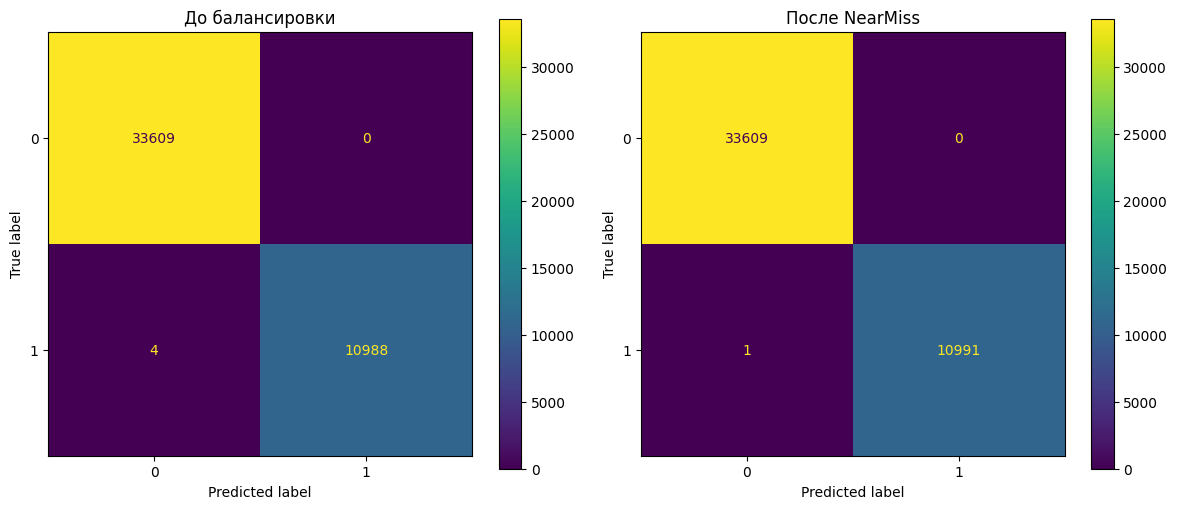

In [36]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

x_train, x_test, y_train, y_test = split_d.get_split(split_d.x, split_d.y)

print('До балансировки:')
print(f"True: {sum(y_train == True)}")
print(f"False: {sum(y_train == False)}")

model_before = LogisticRegression(max_iter=1000)
model_before.fit(x_train, y_train)
pred_before = model_before.predict(x_test)
print("\nОтчет до балансировки:")
print(classification_report(y_test, pred_before))

x_train_nm, y_train_nm = split_d.get_balansing_near_miss(x_train, y_train)
print('\nПосле NearMiss (undersampling):')
print(f"True: {sum(y_train_nm == True)}")
print(f"False: {sum(y_train_nm == False)}")

model_after = LogisticRegression(max_iter=1000)
model_after.fit(x_train_nm, y_train_nm)
pred_after = model_after.predict(x_test)
print("\nОтчет после балансировки:")
print(classification_report(y_test, pred_after))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_before, ax=axes[0])
axes[0].set_title('До балансировки')
ConfusionMatrixDisplay.from_predictions(y_test, pred_after, ax=axes[1])
axes[1].set_title('После NearMiss')
plt.tight_layout()
plt.show()

<small>

Здесь мы лишь посмотрим, как работает модель с балансированной и небалансированной обучающей выборкой — это делается исключительно для визуализации. <br> В обучении мы будем использовать встроенные методы балансировки, такие как NearMiss или SMOTE.  Уже на этом этапе видны слишком идеальные результаты. <br> Далее, на этапе анализа корреляции, будет дано объяснение таким результатам и предложено решение.

</small>

### 🚩 9. Поиск распределения

#### Проверка на нормальное распределение. Тест Колмогорова-Смирнова

Ещё раз проведём тест на нормальное распределение, на этот раз — Колмогорова-Смирнова. Он должен быть менее чувствителен к шуму.

<style>
    table { font-size: 13px; } /* Уменьшаем шрифт */
</style>

Справка
| Тест                | Что проверяет                 | Чувствительность      | Подходит для        | Особенности                       |
|---------------------|------------------------------|----------------------|--------------------|----------------------------------|
| Шапиро-Уилка        | Нормальность                 | Высокая (малые выборки) | Малые и средние     | Очень точный для небольших выборок |
| Колмогоров-Смирнова | Совпадение с распределением  | Средняя              | Любые, большие     | Общий тест, менее чувствителен к хвостам |
| Андерсона-Дарлинга  | Подгонка под распределение   | Высокая (особенно хвосты) | Любые               | Чувствителен к хвостам            |


In [37]:
def kolmogorov_test(df):
    ks_results = {}

    for column in df.columns:
        data = df[column]

        stat_ks, p_value_ks = stats.kstest(data, 'norm')
        ks_results[column] = {
            'KS-statistic': stat_ks,
            'p-value': p_value_ks}

    return ks_results

ks_results = kolmogorov_test(df[df_digit.columns])
for column, result in ks_results.items():
    print(f"Результат для {column}:")
    for test, value in result.items():
        print(f"  {test}: {value:.3f}")
    print("-" * 40)

Результат для loan_amount:
  KS-statistic: 1.000
  p-value: 0.000
----------------------------------------
Результат для rate_of_interest:
  KS-statistic: 0.176
  p-value: 0.000
----------------------------------------
Результат для Interest_rate_spread:
  KS-statistic: 0.142
  p-value: 0.000
----------------------------------------
Результат для Upfront_charges:
  KS-statistic: 0.848
  p-value: 0.000
----------------------------------------
Результат для term:
  KS-statistic: 0.500
  p-value: 0.000
----------------------------------------
Результат для property_value:
  KS-statistic: 1.000
  p-value: 0.000
----------------------------------------
Результат для income:
  KS-statistic: 1.000
  p-value: 0.000
----------------------------------------
Результат для Credit_Score:
  KS-statistic: 0.161
  p-value: 0.000
----------------------------------------
Результат для LTV:
  KS-statistic: 0.199
  p-value: 0.000
----------------------------------------
Результат для dtir1:
  KS-statistic

<style>
    table { font-size: 13px; } /* Уменьшаем шрифт */
</style>

##### 🌟 Результаты теста Колмогорова-Смирнова  

| Переменная           | KS-статистика | p-value |
|----------------------|---------------|---------|
| loan_amount          | 1.000         | 0.000   |
| rate_of_interest     | 0.176         | 0.000   |
| Interest_rate_spread | 0.142         | 0.000   |
| Upfront_charges      | 0.848         | 0.000   |
| term                 | 0.500         | 0.000   |
| property_value       | 1.000         | 0.000   |
| income               | 1.000         | 0.000   |
| Credit_Score         | 0.161         | 0.000   |
| LTV                  | 0.199         | 0.000   |
| dtir1                | 0.162         | 0.000   |


<br>

<small>
KS-статистика — мера максимального отклонения эмпирической функции распределения от теоретической функции нормального распределения. <br> Значения, близкие к 1, указывают на значительное отклонение от нормального распределения.

p-value — вероятность получить наблюдаемые данные при условии, что они следуют нормальному распределению (нулевая гипотеза). <br> Если p-value меньше выбранного уровня значимости (обычно 0.05), нулевая гипотеза отвергается.

В нашем случае для всех переменных p-value равны 0 (меньше 0.05), что означает статистически значимое отклонение от нормального распределения.

---
Вывод по данным

- Многие переменные демонстрируют высокие значения KS-статистики и нулевые p-value, что свидетельствует о значительном отклонении распределений от нормального.

- Даже переменные с относительно меньшими значениями KS-статистики, например Interest_rate_spread, всё равно не проходят тест на нормальность (p-value = 0.000).

- Это указывает на то, что предположение о нормальном распределении не выполняется, даже после логарифмирования и масштабирования некоторых признаков.

</small>

#### Визуализация распределения данных датасета

Посмотри на график Q-Q plot 

<small>
Графики не соответствуют нормальному распределению. Ближе всего к нему находятся переменные: процентная ставка (rate_of_interest), доход (income) <br> и стоимость недвижимости (property_value). У большинства переменных наблюдаются скошенные части. Также заметно существенное <br> сходство в сдвиге между переменными term и Upfront_charges, что может указывать на их взаимосвязь.
</small>



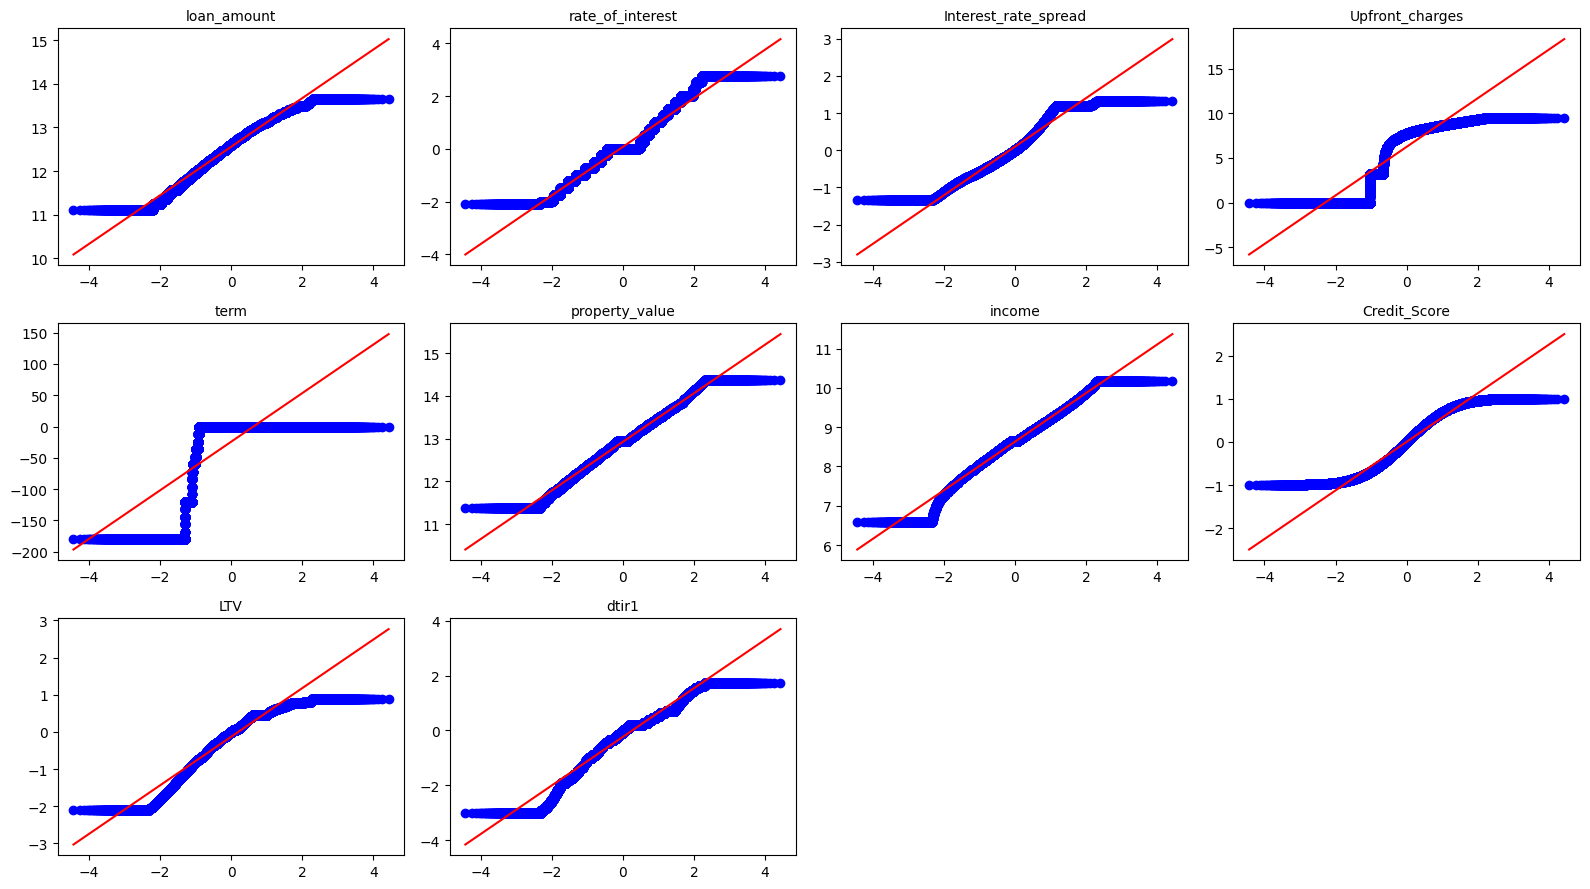

In [38]:
import numpy as np
import matplotlib.pyplot as plt


num_columns = len(df_digit.columns)
num_rows = int(np.ceil(num_columns / 4))
num_cols = min(num_columns, 4)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows * 3))
axes = axes.flatten()

for i, col in enumerate(df_digit.columns):
    stats.probplot(df[col], dist="norm", plot=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Посмотрим на гистограммы

Два одинаковых графика, но с разной компоновкой.

3 4


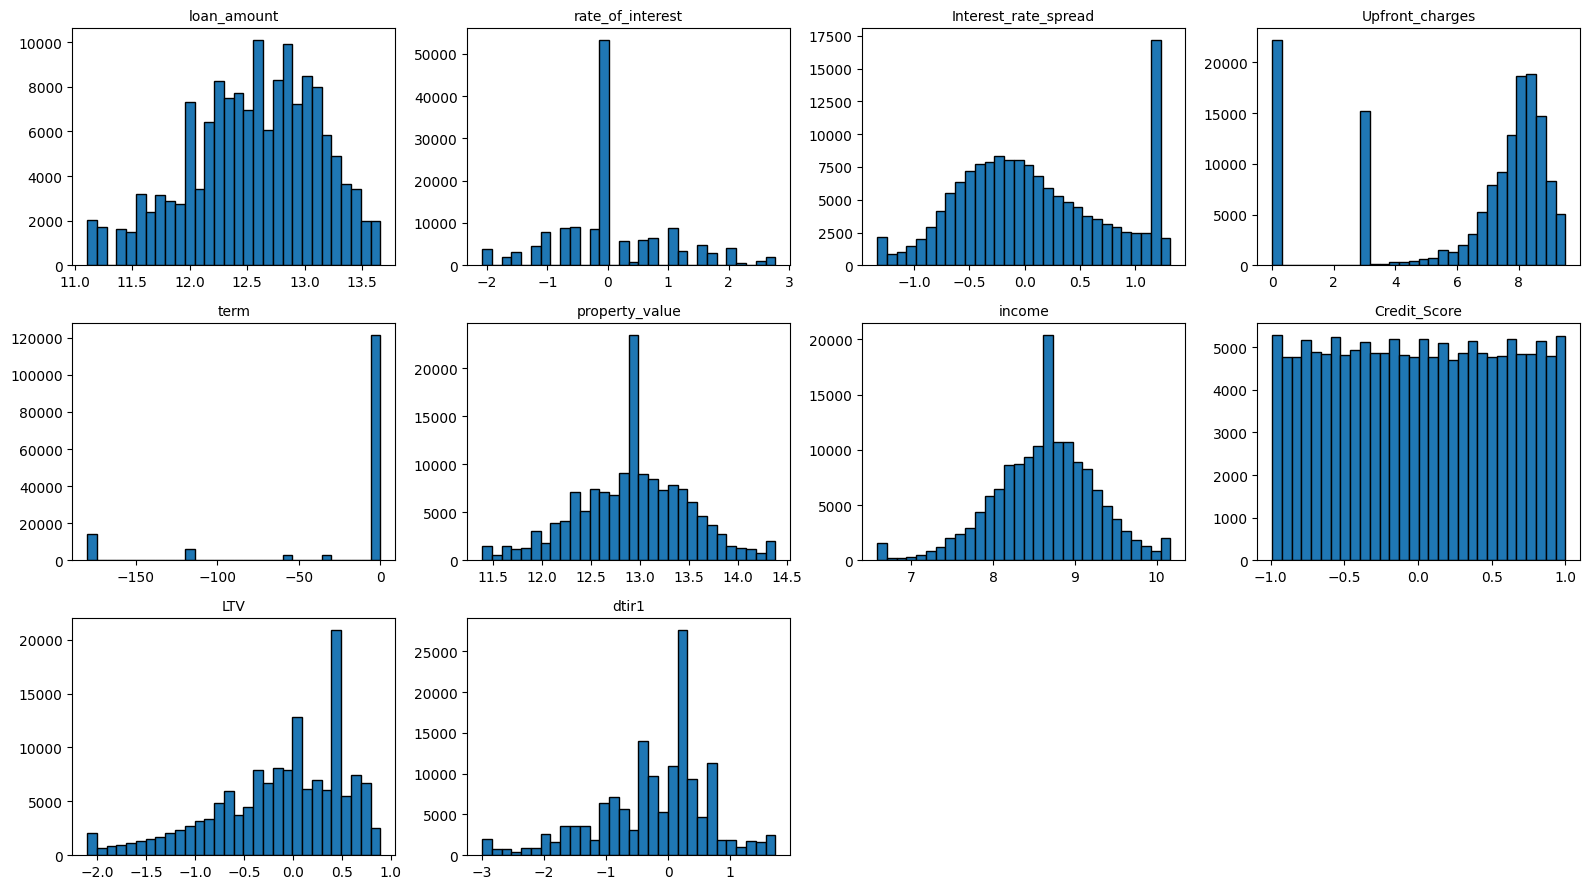

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns


num_columns = len(df_digit.columns)
num_rows = int(np.ceil(num_columns / 4))
num_cols = min(num_columns, 4)
print(num_rows, num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows * 3))
axes = axes.flatten()

for i, col in enumerate(df_digit.columns):
    axes[i].hist(df[col].dropna(), bins=30, edgecolor='black')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

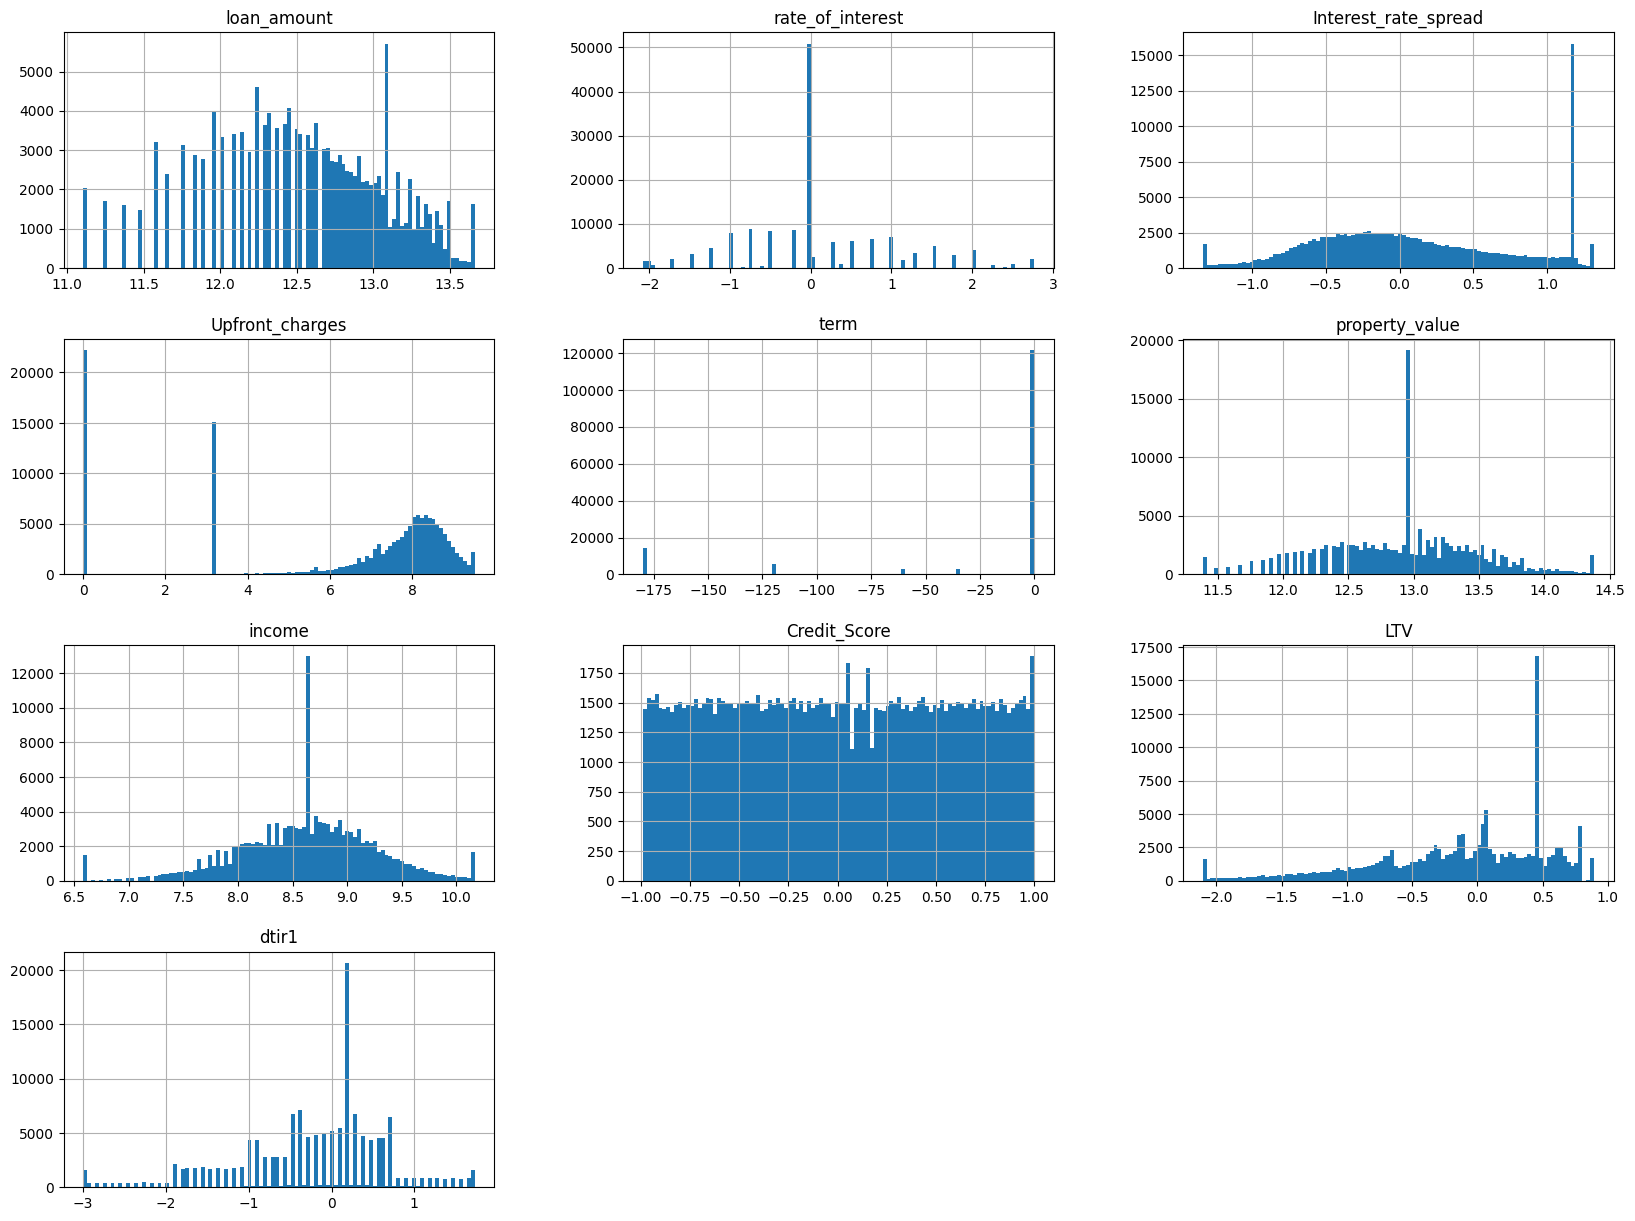

In [ ]:
df[df_digit.columns].hist( bins=100, figsize=(20, 15))

<small>
На гистограммах мы также не наблюдаем нормального распределения, разве что переменные Interest_rate_spread и income <br> максимально приблизились к нему, однако по результатам тестов они нормальность не подтверждают.

Визуально можно предположить, что переменная income имеет распределение, связанное с доходами — часто говорят, что оно близко к логнормальному.
</small>


#### Проверка на логнормальность
<small>
Попробуем логарифмировать датафрейм df_digit, предварительно очищенный только от пропусков и ещё не масштабированный.<br> Посмотрим, удастся ли после этого приблизиться к нормальному распределению.
</small>

In [ ]:
import pandas as pd
import scipy.stats as stats
import numpy as np

def kolmogorov_test(df):
    ks_results = []

    for column in df.columns:
        data = df[column].dropna()

        data = data[data > 0]
        if data.empty:
            continue

        log_data = np.log(data)
        stat_ks, p_value_ks = stats.kstest(log_data, 'norm', args=(log_data.mean(), log_data.std()))

        ks_results.append({
            'column': column,
            'KS-statistic': stat_ks,
            'p-value': p_value_ks
        })

    return pd.DataFrame(ks_results)

ks_results_df = kolmogorov_test(df_digit[df_digit.columns])
print(ks_results_df.sort_values(by="p-value", ascending=True))


                 column  KS-statistic        p-value
1      rate_of_interest      0.185126   0.000000e+00
2  Interest_rate_spread      0.124947   0.000000e+00
3       Upfront_charges      0.185782   0.000000e+00
4                  term      0.478199   0.000000e+00
7          Credit_Score      0.068647   0.000000e+00
5        property_value      0.067950   0.000000e+00
9                 dtir1      0.176264   0.000000e+00
8                   LTV      0.141426   0.000000e+00
0           loan_amount      0.046493  1.037050e-279
6                income      0.042279  2.121676e-229


Данные этих признаков не соответствуют логнормальному распределению, что подтверждается низкими значениями p-value.

#### Проверка на Хи-распределение

Здесь мы будем использовать уже очищенный от выбросов и масштабированный датасет.

In [ ]:
import scipy.stats as stats
import numpy as np

def chi_square_test(df):
    chi_results = {}

    for column in df.columns:
        data = df[column].dropna()

        if data.min() < 0:
            data = data - data.min() + 1e-6

        # Тест Колмогорова-Смирнова на хи-квадрат распределение
        df_fit = stats.chi2.fit(data)
        stat_ks, p_value_ks = stats.kstest(data, 'chi2', args=df_fit)

        chi_results[column] = {
            'KS-statistic': stat_ks,
            'p-value': p_value_ks
        }

    return chi_results

chi_results = chi_square_test(df[df_digit.columns])

for column, result in chi_results.items():
    print(f"Результат для {column}:")
    for test, value in result.items():
        print(f"  {test}: {value:.3f}")
    print("-" * 40)


Результат для loan_amount:
  KS-statistic: 0.448
  p-value: 0.000
----------------------------------------
Результат для rate_of_interest:
  KS-statistic: 0.295
  p-value: 0.000
----------------------------------------
Результат для Interest_rate_spread:
  KS-statistic: 0.066
  p-value: 0.000
----------------------------------------
Результат для Upfront_charges:
  KS-statistic: 0.603
  p-value: 0.000
----------------------------------------
Результат для term:
  KS-statistic: 0.876
  p-value: 0.000
----------------------------------------
Результат для property_value:
  KS-statistic: 0.083
  p-value: 0.000
----------------------------------------
Результат для income:
  KS-statistic: 0.060
  p-value: 0.000
----------------------------------------
Результат для Credit_Score:
  KS-statistic: 0.064
  p-value: 0.000
----------------------------------------
Результат для LTV:
  KS-statistic: 0.298
  p-value: 0.000
----------------------------------------
Результат для dtir1:
  KS-statistic

Данные этих числовых признаков не проходят по P-value под хи-распределение

#### Проверка на Гамма-распределение

Здесь мы будем использовать уже очищенный от выбросов и масштабированный датасет

In [ ]:
import scipy.stats as stats
import numpy as np

def gamma_test(df):
    gamma_results = {}

    for column in df.columns:
        data = df[column]
        data = data[np.isfinite(data)]

        data = data[data > 0]
        if data.empty:
            continue


        if data.min() <= 0:
            print(f"Данные в столбце {column} содержат значения <= 0, что недопустимо для гамма-распределения.")
            continue

        # Тест Колмогорова-Смирнова на гамма-распределение
        try:
            df_fit = stats.gamma.fit(data)
            stat_ks, p_value_ks = stats.kstest(data, 'gamma', args=df_fit)
            gamma_results[column] = {
                'KS-statistic': stat_ks,
                'p-value': p_value_ks
            }
        except Exception as e:
            print(f"Ошибка при подгонке для столбца {column}: {e}")
            gamma_results[column] = {
                'KS-statistic': None,
                'p-value': None
            }

    return gamma_results

gamma_results = gamma_test(df[df_digit.columns])

for column, result in gamma_results.items():
    print(f"Результат для {column}:")
    for test, value in result.items():
        print(f"  {test}: {value}")
    print("-" * 40)


Результат для loan_amount:
  KS-statistic: 0.058941206805918744
  p-value: 0.0
----------------------------------------
Результат для rate_of_interest:
  KS-statistic: 0.0943361455718788
  p-value: 0.0
----------------------------------------
Результат для Interest_rate_spread:
  KS-statistic: 0.1407381629264146
  p-value: 0.0
----------------------------------------
Результат для Upfront_charges:
  KS-statistic: 0.19338858775949802
  p-value: 0.0
----------------------------------------
Результат для property_value:
  KS-statistic: 0.07445381618260294
  p-value: 0.0
----------------------------------------
Результат для income:
  KS-statistic: 0.06119159547733466
  p-value: 0.0
----------------------------------------
Результат для Credit_Score:
  KS-statistic: 0.059650778508747226
  p-value: 3.394785948107145e-230
----------------------------------------
Результат для LTV:
  KS-statistic: 0.12613183166890024
  p-value: 0.0
----------------------------------------
Результат для dtir1:

Данные этих числовых признаков не проходят по P-value под гамма-распределение

#### Результаты тестов 

Как видно из таблицы, ни одна из переменных не прошла тесты на соответствие ни одному из проверяемых распределений


**Легенда:**  
✗ — переменная не прошла тест на соответствие распределению <br>
✓ — переменная прошла тест на соответствие распределению

| Переменная           | Нормальное | Логнормальное | Гамма | Хи-квадрат |
|----------------------|------------|---------------|-------|------------|
| loan_amount          | ✗          | ✗             | ✗     | ✗          |
| rate_of_interest     | ✗          | ✗             | ✗     | ✗          |
| Interest_rate_spread | ✗          | ✗             | ✗     | ✗          |
| Upfront_charges      | ✗          | ✗             | ✗     | ✗          |
| term                 | ✗          | ✗             | ✗     | ✗          |
| property_value       | ✗          | ✗             | ✗     | ✗          |
| income               | ✗          | ✗             | ✗     | ✗          |
| Credit_Score         | ✗          | ✗             | ✗     | ✗          |
| LTV                  | ✗          | ✗             | ✗     | ✗          |
| dtir1                | ✗          | ✗             | ✗     | ✗          |


###  👨‍🏫 10. Корреляционный анализ

Поиск корреляции между бинарными, порядковыми категориальными и целевой

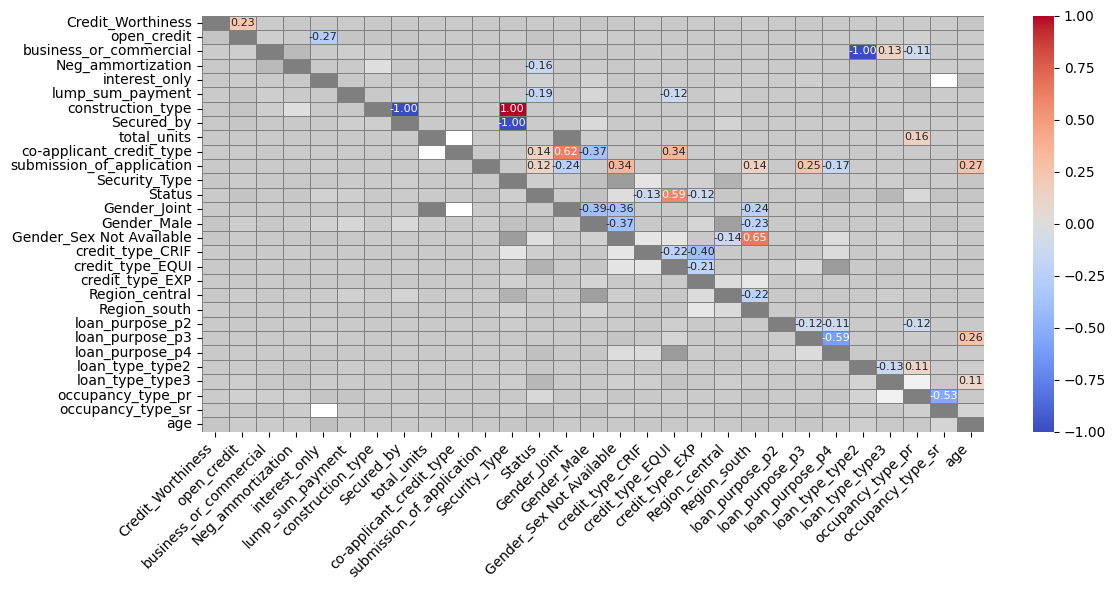

Neg_ammortization - Status: -0.16
lump_sum_payment - Status: -0.19
co-applicant_credit_type - Status: 0.14
submission_of_application - Status: 0.12
Status - credit_type_CRIF: -0.13
Status - credit_type_EQUI: 0.59
Status - credit_type_EXP: -0.12


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
shield = 0.1

indicators = ['rate_of_interest_missing', 'property_value_missing', 'income_missing', 'loan_limit_missing',
        'approv_in_adv_missing', 'loan_purpose_missing', 'Neg_ammortization_missing', 'submission_of_application_missing',
        'age_missing']

cat_bin_cols = [col for col in df.columns if df[col].nunique() == 2] + ['age']
df_binary = df[cat_bin_cols].drop(columns=indicators, inplace=False)

corr_matrix = df_binary.corr(method='spearman')
mask_strong = (np.abs(corr_matrix) > shield).values
np.fill_diagonal(mask_strong, False)
strong_vars = corr_matrix.columns[mask_strong.any(axis=1)].tolist()

df_filtered_binary = df_binary[strong_vars]
filtered_corr = df_filtered_binary.corr(method='spearman')

mask_weak = np.abs(filtered_corr) < shield
mask_triangle = np.tril(np.ones(filtered_corr.shape), k=0).astype(bool)
mask = mask_weak | mask_triangle

np.fill_diagonal(filtered_corr.values, np.nan)
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, cmap='Greys', annot=False, cbar=False, alpha=0.5)
sns.heatmap(filtered_corr, cmap='coolwarm', annot=True, fmt='.2f', alpha=1,
            mask=mask, linewidths=0.5, linecolor='gray', annot_kws={"size": 8}, cbar=True)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > shield:
            if corr_matrix.columns[i] == 'Status' or corr_matrix.columns[j] == 'Status':
                print(f"{corr_matrix.columns[i]} - {corr_matrix.columns[j]}: {corr_val:.2f}")

Корреляционный анализ между индикаторами и целевой переменной

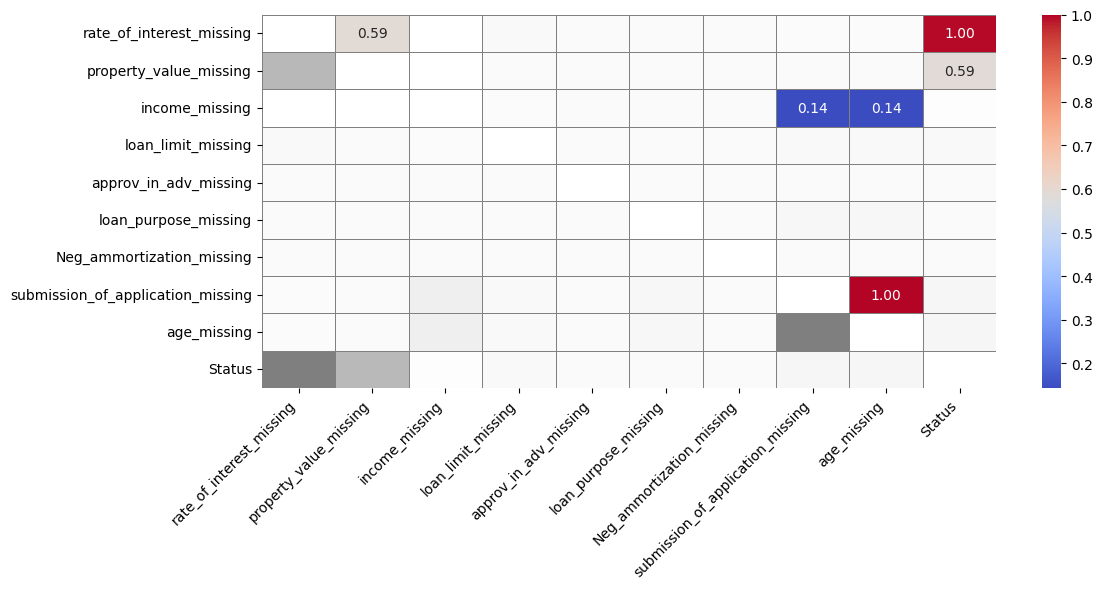

rate_of_interest_missing - Status: 1.00
property_value_missing - Status: 0.59


In [45]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
shield = 0.1


indicators_and_status = ['rate_of_interest_missing', 'property_value_missing', 'income_missing', 'loan_limit_missing',
        'approv_in_adv_missing', 'loan_purpose_missing', 'Neg_ammortization_missing', 'submission_of_application_missing',
        'age_missing', 'Status']

df_indicators_corr = df[indicators_and_status]
corr_matrix = df_indicators_corr.corr(method='spearman')

mask_weak = np.abs(corr_matrix) < shield
mask_triangle = np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool)
mask = mask_weak | mask_triangle

np.fill_diagonal(corr_matrix.values, np.nan)
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, cmap='Greys', annot=False, cbar=False, alpha=0.5)
sns.heatmap(corr_matrix, mask=mask, linewidths=0.5, linecolor='gray', annot=True, cmap='coolwarm', fmt='.2f', alpha=1)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > shield:
                if corr_matrix.columns[i] == 'Status' or corr_matrix.columns[j] == 'Status':
                      print(f"{corr_matrix.columns[i]} - {corr_matrix.columns[j]}: {corr_val:.2f}")

Корреляционный анализ между числовыми и целевой переменной

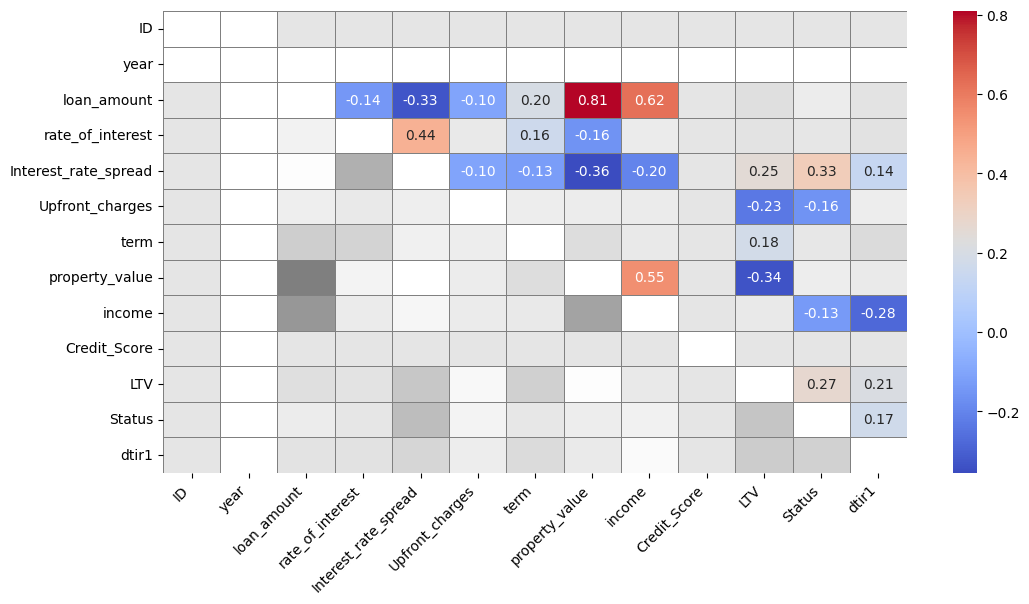

Interest_rate_spread - Status: 0.33
Upfront_charges - Status: -0.16
income - Status: -0.13
LTV - Status: 0.27
Status - dtir1: 0.17


In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
shield = 0.1

corr_matrix = df_digit_corr.corr(method='spearman')
mask_weak = np.abs(corr_matrix) < shield
mask_triangle = np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool)
mask = mask_weak | mask_triangle

np.fill_diagonal(corr_matrix.values, np.nan)
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, cmap='Greys', annot=False, cbar=False, alpha=0.5)
sns.heatmap(corr_matrix, mask=mask, annot=True, linewidths=0.5, linecolor='gray', cmap='coolwarm', fmt='.2f', alpha=1)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > shield:
            if corr_matrix.columns[i] == 'Status' or corr_matrix.columns[j] == 'Status':
                print(f"{corr_matrix.columns[i]} - {corr_matrix.columns[j]}: {corr_val:.2f}")

#### Корреляция признаков с целевой переменной
<small> Корреляция по Спирмену

<style>
    table { font-size: 13px; } /* Уменьшаем шрифт */
</style>


 Индикаторы

| Переменная               | Корреляция с Status | 
|--------------------------|---------------------|   
| rate_of_interest_missing | 1.00 🔥             |            
| property_value_missing   | 0.59 🔥             |              

Это искусственные переменные, отмечающие пропуски. Скорее всего, из-за отсутствия данных допущена утечка информации <br> или существует неявная связь между отсутствием ставки и дефолтом по кредиту, что объясняет высокую корреляцию.

В любом случае их использование делает задачу классификации слишком простой, что ранее было видно при визуализации <br> дисбаланса классов — все метрики становятся идеальными.


<br>

 Числовые
| Переменная           | Корреляция с Status |  
|----------------------|---------------------|
| Interest_rate_spread | 0.33 🔥             |  
| LTV                  | 0.27 🔥             |  
| dtir1                | 0.17                |  
| income               | -0.13               |  

Видим неожиданно хорошую связь между `LTV` и целевой переменной. Ранее я, возможно, ошибочно полагал, что раз у нас есть <br> loan_amount и `income`, мы сможем воспроизвести `LTV`. Думаю, стоит её оставить — она, вероятно, является важной переменной. <br> То же самое касается `Interest_rate_spread`.



<br>

Бинарные

| Переменная               | Корреляция с Status |  
|--------------------------|---------------------|  
| credit_type_EQUI         | 0.59 🔥             |  
| co-applicant_credit_type | 0.14                |  
| submission_of_application| 0.12                |  
| credit_type_CRIF         | -0.13               |  
| credit_type_EXP          | -0.12               |  
| Neg_ammortization        | -0.16               |  
| lump_sum_payment         | -0.19               |  


Здесь видим большой вес у `credit_type_EQUI` - credit_type_EQUI имеет высокую корреляцию с целевой переменной, <br> что может быть как полезным признаком, так и признаком утечки данных. Пробовал её удалить — на одних моделях результаты становятся лучше, на других — хуже.



#### Удаление признаков

Можно удалить `rate_of_interest_missing`, `property_value_missing` (опционально)

In [47]:
df.drop(columns=['construction_type', 'Security_Type', 'Secured_by'], inplace=True)
df.drop(columns=['submission_of_application_missing', 'Neg_ammortization_missing',
                 'loan_purpose_missing', 'age_missing'], inplace=True)

df.drop(columns=['ID', 'year'], inplace=True)

df.drop(columns=['rate_of_interest_missing', 'property_value_missing'], inplace=True)
# df.drop(columns=['LTV', 'Interest_rate_spread'], inplace=True)

Можно попробовать `credit_type_EQUI` удалить (опционально)

In [48]:
# df.drop(columns=['credit_type_EQUI'], inplace=True)

### 🎨 11. Обучение моделей


#### Общие части

In [ ]:
from sklearn.model_selection import cross_validate
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import NearMiss
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, make_scorer, balanced_accuracy_score, roc_auc_score


def plot_confusion_matrix(y_test, y_pred):

    plt.figure(figsize=(8, 5))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap=plt.cm.Blues)
    plt.title('Матрица ошибок')
    plt.tight_layout()
    plt.show()

def report(y_test, y_pred):
    print("\nОтчет о классификации:")
    print(classification_report(y_test, y_pred))


def train_and_evaluate(pipe, cv=5):

    print(f'Общий прогноз на тестовой выборке:')
    pipe.fit(x_train, y_train)
    y_pred = pipe.predict(x_test)
    report(y_test, y_pred)
    plot_confusion_matrix(y_test, y_pred)

    print(f'-----------------------------------------------------')
    print(f'\n Основные результаты кросс-валидации (cv={cv}):')

    scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'balanced_accuracy': make_scorer(balanced_accuracy_score)
    }

    scores = cross_validate(pipe, split_d.x, split_d.y, cv=cv, scoring=scoring)

    print(f"Средняя accuracy (CV): {scores['test_accuracy'].mean():.4f}")
    print(f"Стандартное отклонение accuracy (CV): {scores['test_accuracy'].std():.4f}")

    print(f"Среднее precision (CV): {scores['test_precision'].mean():.4f}")
    print(f"Стандартное отклонение precision (CV): {scores['test_precision'].std():.4f}")

    print(f"Среднее recall (CV): {scores['test_recall'].mean():.4f}")
    print(f"Стандартное отклонение recall (CV): {scores['test_recall'].std():.4f}")

    print(f"Среднее f1 (CV): {scores['test_f1'].mean():.4f}")
    print(f"Стандартное отклонение f1 (CV): {scores['test_f1'].std():.4f}")

    print(f'-----------------------------------------------------')
    print(f'\n Дополнительные результаты кросс-валидации (cv={cv}):')

    print(f"Среднее roc_auc (CV): {scores['test_roc_auc'].mean():.4f}")
    print(f"Среднее balanced_accuracy (CV): {scores['test_balanced_accuracy'].mean():.4f}")


    print(f'Тестовая оценка')
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Accuracy:          {acc:.4f}")
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    print(f"Precision:         {prec:.4f}")
    print(f"Recall:            {rec:.4f}")
    print(f"F1-score:          {f1:.4f}")


split_d = SplitData(df)
x_train, x_test, y_train, y_test = split_d.get_split(split_d.x, split_d.y)
x_train_nm, y_train_nm = split_d.get_balansing_near_miss(x_train, y_train)

##### Sanity check общий

In [50]:
import numpy as np
y_train_random = np.random.permutation(y_train)

def sanity_check(pipe, cv=2):

    print(f'Общий прогноз на тестовой выборке:')
    pipe.fit(x_train, y_train_random)
    y_pred = pipe.predict(x_test)
    report(y_test, y_pred)
    plot_confusion_matrix(y_test, y_pred)

    # print(f'\nРезультаты кросс-валидации (cv={cv}):')
    # scores = cross_val_score(pipe, split_d.x, split_d.y, cv=cv, scoring='accuracy')
    # print(f'Средняя accuracy (CV): {scores.mean():.4f}')
    # print(f'Стандартное отклонение accuracy (CV): {scores.std():.4f}')


#### One Rule

In [ ]:
import pandas as pd
from typing import Tuple, Dict

def one_rule(df: pd.DataFrame, target_col: pd.Series) -> Tuple[str, Dict, int]:


    target_name = target_col.name
    if target_name not in df.columns or df.empty:
        raise ValueError("Целевая колонка отсутствует или DataFrame пуст")

    num_features = ['Interest_rate_spread', 'LTV', 'loan_amount', 'property_value', 'income', 'Upfront_charges',
                       'dtir1', 'rate_of_interest', 'term', 'Credit_Score']

    df_binned = df.copy()

    for feature in num_features:
        df_binned[feature] = pd.cut(df_binned[feature], bins=5).cat.codes # Биннинг

    print(df_binned)
    errors = {}
    rules = {}

    for col in df_binned.columns:
        if col == target_name:
            continue

        counts = df_binned.groupby([col, target_name]).size().unstack(fill_value=0)

        majority_classes = counts.idxmax(axis=1)
        rule = majority_classes.to_dict()
        total_error = int((counts.sum(axis=1) - counts.max(axis=1)).sum())

        rules[col] = rule
        errors[col] = total_error


    best_feature = min(errors, key=errors.get)
    return best_feature, rules[best_feature], errors, rules


best_feature, best_rule, errors, rules = one_rule(split_d.df, y_train_nm)
print(f"Лучший признак: {best_feature}")

        loan_limit  approv_in_adv  Credit_Worthiness  open_credit  \
0                0              0                0.0            0   
1                0              0                0.0            0   
2                0              1                0.0            0   
3                0              0                0.0            0   
4                0              1                0.0            0   
...            ...            ...                ...          ...   
148665           0              0                0.0            0   
148666           0              0                0.0            0   
148667           0              0                0.0            0   
148668           0              0                0.0            0   
148669           0              0                0.0            0   

        business_or_commercial  loan_amount  rate_of_interest  \
0                            1            2                 4   
1                            0           

Смотрим на тесты и делаем предсказание


Отчет о классификации:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91     33609
           1       1.00      0.42      0.59     10992

    accuracy                           0.86     44601
   macro avg       0.92      0.71      0.75     44601
weighted avg       0.88      0.86      0.83     44601



<Figure size 800x500 with 0 Axes>

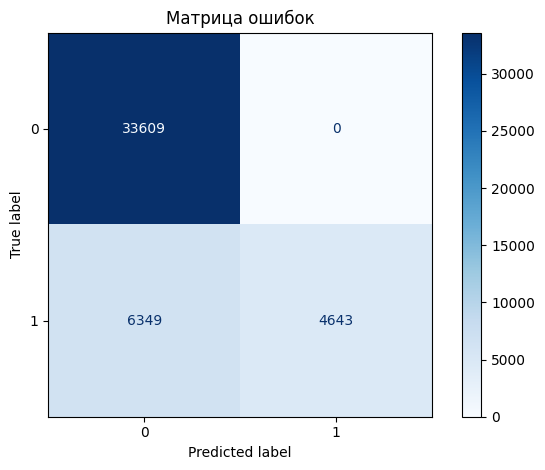

Accuracy:          0.8576
Balanced Accuracy: 0.7112
Precision:         1.0000
Recall:            0.4224
F1-score:          0.5939


In [105]:
def classify_by_rule(row):
    val = row[best_feature]
    return best_rule.get(val)

y_pred = pd.DataFrame()
y_pred['Predicted'] = x_test.apply(classify_by_rule, axis=1)

report(y_test, y_pred)
plot_confusion_matrix(y_test, y_pred)

bal_acc = balanced_accuracy_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:          {acc:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"Precision:         {prec:.4f}")
print(f"Recall:            {rec:.4f}")
print(f"F1-score:          {f1:.4f}")


#### Логистическая регрессия

Общий прогноз на тестовой выборке:

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88     33609
           1       0.62      0.67      0.64     10992

    accuracy                           0.82     44601
   macro avg       0.75      0.77      0.76     44601
weighted avg       0.82      0.82      0.82     44601



d:\Python Language\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<Figure size 800x500 with 0 Axes>

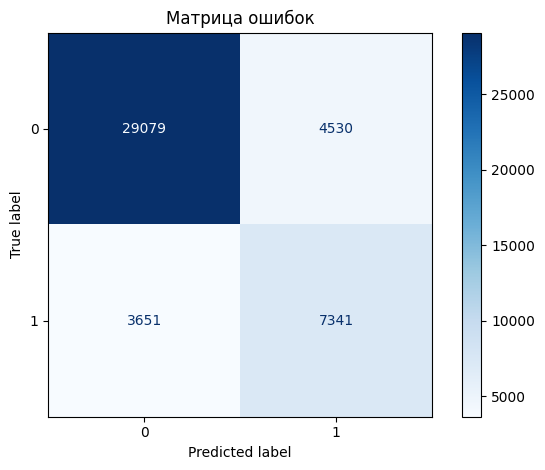

-----------------------------------------------------

 Основные результаты кросс-валидации (cv=5):


d:\Python Language\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
d:\Python Language\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_o

Средняя accuracy (CV): 0.8160
Стандартное отклонение accuracy (CV): 0.0017
Среднее precision (CV): 0.6184
Стандартное отклонение precision (CV): 0.0039
Среднее recall (CV): 0.6624
Стандартное отклонение recall (CV): 0.0021
Среднее f1 (CV): 0.6396
Стандартное отклонение f1 (CV): 0.0026
-----------------------------------------------------

 Дополнительные результаты кросс-валидации (cv=5):
Среднее roc_auc (CV): 0.8424
Среднее balanced_accuracy (CV): 0.7643
Тестовая оценка
Accuracy:          0.8166
Balanced Accuracy: 0.7665
Precision:         0.6184
Recall:            0.6678
F1-score:          0.6422


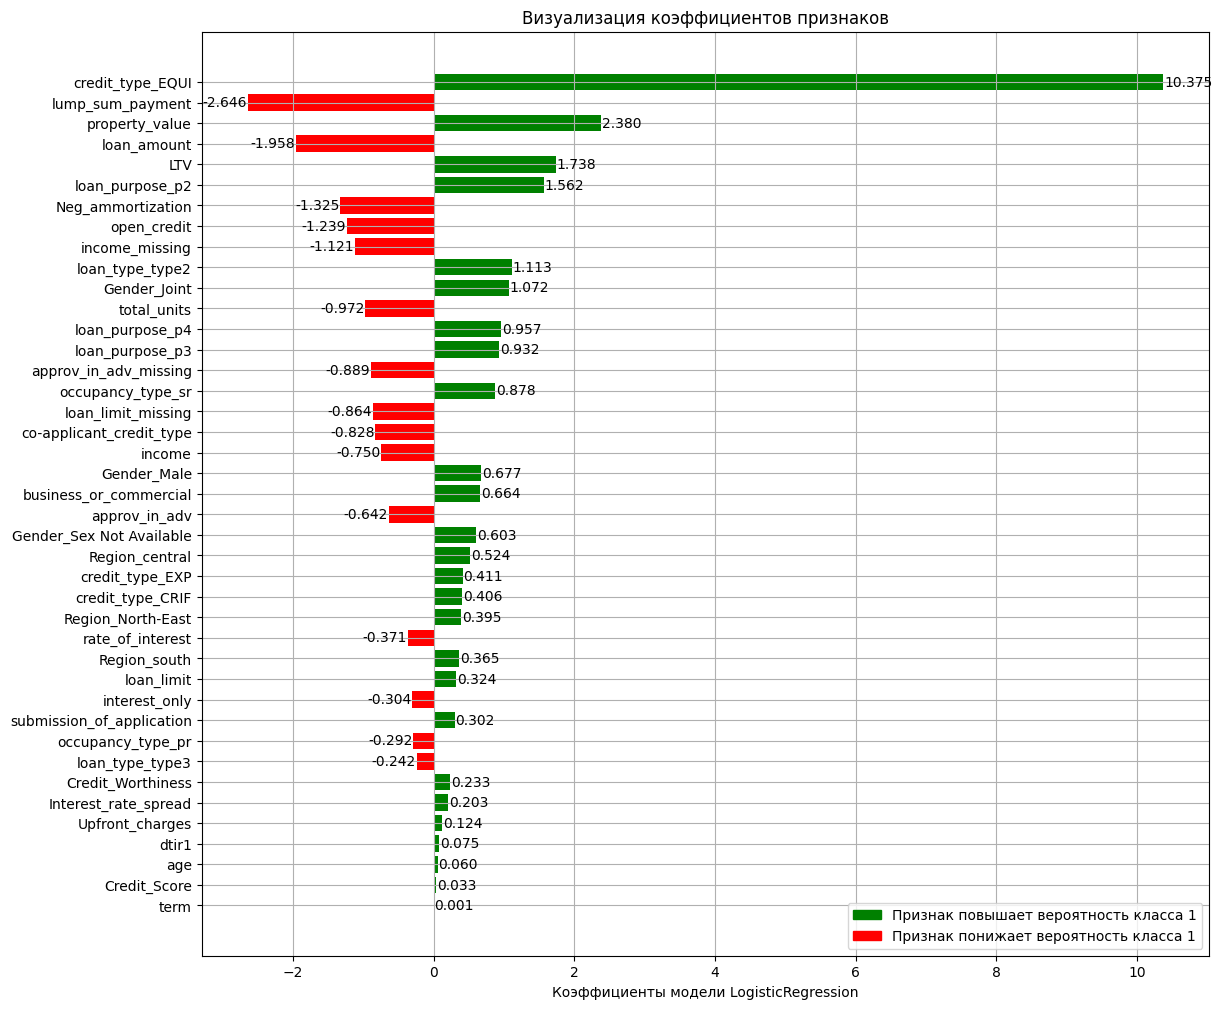

In [ ]:
from sklearn.linear_model import LogisticRegression
import matplotlib.patches as mpatches

# class_weight='balanced' автоматически задаёт веса для классов обратно пропорционально их частоте в обучающей выборке.
# Таким образом, ошибки на редком классе "дороже" для модели, и она пытается их минимизировать сильнее.

pipe_log = Pipeline([
    ('smote', SMOTE()),
    ('model',  LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ])


train_and_evaluate(pipe_log)

def log_coef_plot(pipe):

    coef = pipe.named_steps['model'].coef_[0]
    sorted_idx = np.argsort(np.abs(coef))
    feature_names = x_train.columns if hasattr(x_train, 'columns') else [f'feat_{i}' for i in range(len(coef))]
    colors = ['green' if c > 0 else 'red' for c in coef[sorted_idx]]
    plt.figure(figsize=(13, 12))
    bars = plt.barh(np.array(feature_names)[sorted_idx], coef[sorted_idx], color=colors)
    plt.xlabel('Коэффициенты модели LogisticRegression')
    plt.title('Визуализация коэффициентов признаков')
    plt.grid(True)

    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.01 * np.sign(width), bar.get_y() + bar.get_height()/2,
                f'{width:.3f}',
                va='center',
                ha='left' if width > 0 else 'right',
                color='black',
                fontsize=10)

    green_patch = mpatches.Patch(color='green', label='Признак повышает вероятность класса 1')
    red_patch = mpatches.Patch(color='red', label='Признак понижает вероятность класса 1')
    plt.legend(handles=[green_patch, red_patch], loc='lower right')
    plt.show()

log_coef_plot(pipe_log)


Общий прогноз на тестовой выборке:

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.77      0.56      0.65     33609
           1       0.27      0.48      0.34     10992

    accuracy                           0.54     44601
   macro avg       0.52      0.52      0.50     44601
weighted avg       0.64      0.54      0.57     44601



d:\Python Language\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<Figure size 800x500 with 0 Axes>

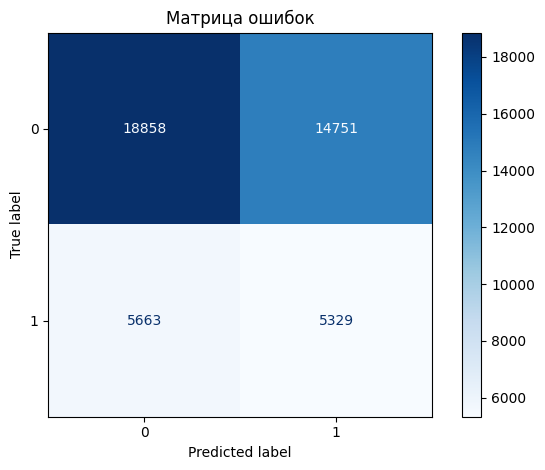

In [ ]:
sanity_check(pipe_log)

#### k - ближайших соседей

Общий прогноз на тестовой выборке:

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92     33609
           1       0.74      0.81      0.77     10992

    accuracy                           0.88     44601
   macro avg       0.84      0.86      0.85     44601
weighted avg       0.89      0.88      0.88     44601



<Figure size 800x500 with 0 Axes>

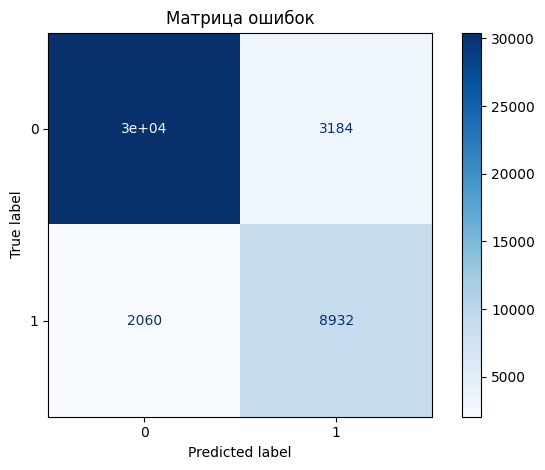

-----------------------------------------------------

 Основные результаты кросс-валидации (cv=5):
Средняя accuracy (CV): 0.8799
Стандартное отклонение accuracy (CV): 0.0017
Среднее precision (CV): 0.7316
Стандартное отклонение precision (CV): 0.0031
Среднее recall (CV): 0.8096
Стандартное отклонение recall (CV): 0.0051
Среднее f1 (CV): 0.7686
Стандартное отклонение f1 (CV): 0.0034
-----------------------------------------------------

 Дополнительные результаты кросс-валидации (cv=5):
Среднее roc_auc (CV): 0.9319
Среднее balanced_accuracy (CV): 0.8562
Тестовая оценка
Accuracy:          0.8824
Balanced Accuracy: 0.8589
Precision:         0.7372
Recall:            0.8126
F1-score:          0.7731


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

'''n_neighbors=6
Количество соседей, которые будут учитываться при классификации или регрессии. В данном случае — 6 ближайших точек.

Метрика расстояния: это параметр для Minkowski distance.
p=1 — это Манхэттенское (L1) расстояние, сумма абсолютных разностей по координатам.
Если бы p=2 — Евклидово (L2) расстояние.

weights='distance'
Взвешивание соседей при голосовании (классификация) или усреднении (регрессия).
'distance' — вес соседей обратно пропорционален расстоянию: ближе соседи имеют больший вес.
Альтернативно можно было указать 'uniform' — все соседи равны по весу.'''


pipe_knn = Pipeline([
    ('smote', SMOTE(random_state=97)),
    ('model',  KNeighborsClassifier(n_neighbors=6, p=1, weights='distance'))
])

train_and_evaluate(pipe_knn)


<small>

Код снизу для поиска лучших параметров <br>

Лучшие параметры: {'knn__n_neighbors': 9, 'knn__p': 1, 'knn__weights': 'distance'} <br>
Лучшее f1 на кросс-валидации: 0.7688326304238624

In [56]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'knn__n_neighbors': [3, 5, 7, 9],
#     'knn__weights': ['uniform', 'distance'],
#     'knn__p': [1, 2]
# }

# grid_search = GridSearchCV(pipe_knn, param_grid, cv=5, scoring='f1', n_jobs=-1)
# grid_search.fit(x_train, y_train)

# print("Лучшие параметры:", grid_search.best_params_)
# print("Лучшее f1 на кросс-валидации:", grid_search.best_score_)


#### Деревья решений

Общий прогноз на тестовой выборке:

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     33609
           1       0.86      0.90      0.88     10992

    accuracy                           0.94     44601
   macro avg       0.91      0.92      0.92     44601
weighted avg       0.94      0.94      0.94     44601



<Figure size 800x500 with 0 Axes>

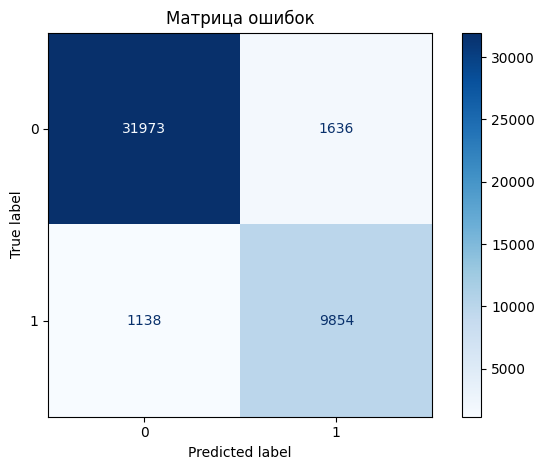

-----------------------------------------------------

 Основные результаты кросс-валидации (cv=5):
Средняя accuracy (CV): 0.9382
Стандартное отклонение accuracy (CV): 0.0021
Среднее precision (CV): 0.8539
Стандартное отклонение precision (CV): 0.0045
Среднее recall (CV): 0.9038
Стандартное отклонение recall (CV): 0.0044
Среднее f1 (CV): 0.8781
Стандартное отклонение f1 (CV): 0.0040
-----------------------------------------------------

 Дополнительные результаты кросс-валидации (cv=5):
Среднее roc_auc (CV): 0.9542
Среднее balanced_accuracy (CV): 0.9266
Тестовая оценка
Accuracy:          0.9378
Balanced Accuracy: 0.9239
Precision:         0.8576
Recall:            0.8965
F1-score:          0.8766


In [ ]:
from sklearn.tree import DecisionTreeClassifier

'''

criterion='entropy'
Критерий качества разбиения узлов дерева.
'entropy' — используется энтропия (информационная теория) для измерения чистоты узлов.

Альтернативно: 'gini' — критерий Джини.

min_samples_leaf=4
Минимальное количество образцов (объектов) в листовом узле.
Узел не будет разбиваться, если после разбиения в листе будет меньше 4 объектов. Помогает избежать переобучения.

min_samples_split=10
Минимальное число образцов, необходимое для разбиения внутреннего узла.
 Узел не будет разбиваться, если в нем меньше 10 образцов.'''


pipe_tree = Pipeline([
    ('smote', SMOTE(random_state=97)),
    ('model', DecisionTreeClassifier(
        random_state=42,
        criterion='entropy',
        min_samples_leaf=4,
        min_samples_split=10
    ))
])

train_and_evaluate(pipe_tree)


<small>
Код снизу для поиска лучших параметров <br>
</small>

In [ ]:

# pipe_tree = Pipeline([
#     ('smote', SMOTE(random_state=97)),
#     ('tree', DecisionTreeClassifier(random_state=42))
# ])

# param_grid = {
#     'tree__max_depth': [5, 10, 20, None],
#     'tree__min_samples_split': [2, 5, 10],
#     'tree__min_samples_leaf': [1, 2, 4],
#     'tree__criterion': ['gini', 'entropy']
# }

# n_jobs=-1 — использование всех доступных процессорных ядер для параллельного вычисления, чтобы ускорить поиск.
# grid_search = GridSearchCV(pipe_tree, param_grid, scoring='f1', cv=5, n_jobs=-1)
# grid_search.fit(x_train, y_train)

# print("Лучшие параметры:", grid_search.best_params_)
# print("Лучшая F1:", grid_search.best_score_)

'''Лучшие параметры: {'tree__criterion': 'entropy', 'tree__max_depth': None, 'tree__min_samples_leaf': 4, 'tree__min_samples_split': 10}
Лучшая F1: 0.8714572242297678'''

#### Наивный Байес

Общий прогноз на тестовой выборке:

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93     33609
           1       0.90      0.59      0.71     10992

    accuracy                           0.88     44601
   macro avg       0.89      0.78      0.82     44601
weighted avg       0.89      0.88      0.87     44601



<Figure size 800x500 with 0 Axes>

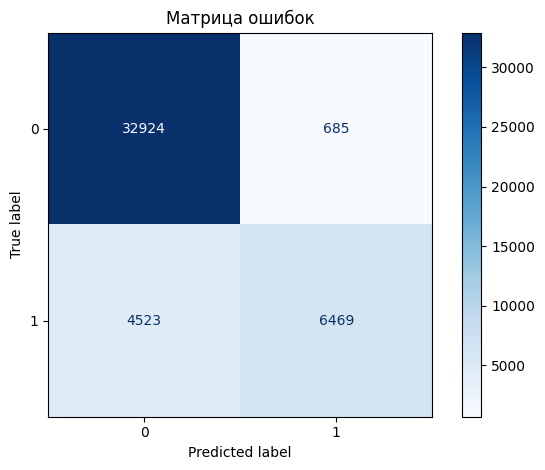

-----------------------------------------------------

 Основные результаты кросс-валидации (cv=5):
Средняя accuracy (CV): 0.8810
Стандартное отклонение accuracy (CV): 0.0026
Среднее precision (CV): 0.9072
Стандартное отклонение precision (CV): 0.0029
Среднее recall (CV): 0.5763
Стандартное отклонение recall (CV): 0.0132
Среднее f1 (CV): 0.7047
Стандартное отклонение f1 (CV): 0.0094
-----------------------------------------------------

 Дополнительные результаты кросс-валидации (cv=5):
Среднее roc_auc (CV): 0.9539
Среднее balanced_accuracy (CV): 0.7785
Тестовая оценка
Accuracy:          0.8832
Balanced Accuracy: 0.7841
Precision:         0.9042
Recall:            0.5885
F1-score:          0.7130


In [91]:
from sklearn.naive_bayes import GaussianNB

pipe_NB = Pipeline([
    ('smote', SMOTE(random_state=97)),
    ('model', GaussianNB())
])

train_and_evaluate(pipe_NB)


#### Градиентный бустинг 

In [ ]:
'''
n_estimators=100
Количество деревьев (базовых моделей), которые будут построены в ансамбле.
Больше — потенциально лучше, но дольше обучается и может привести к переобучению.

learning_rate=0.1
Скорость обучения — уменьшает вклад каждого дерева в итоговый результат,
помогает избежать переобучения. Чем меньше, тем дольше обучение, но лучше обобщение.

max_depth=10
Максимальная глубина каждого дерева. Глубже дерево — сложнее модель, может
 лучше запомнить данные, но рискует переобучиться.

min_samples_split=10
Минимальное количество объектов, необходимых для разбиения узла дерева.
 Если меньше — узел не будет делиться. Помогает контролировать переобучение.

min_samples_leaf=6
Минимальное количество объектов, которое должно быть в листовом узле дерева.
Позволяет сделать модель более устойчивой и менее подверженной переобучению.

subsample=0.7
Доля случайно выбранных объектов (70%) для построения каждого дерева.
 Используется для стохастического градиентного бустинга, что помогает снизить переобучение.

max_features='sqrt'
Количество признаков, которое будет случайно выбрано при поиске лучшего разбиения в каждом узле.
 'sqrt' — означает взять квадратный корень из общего числа признаков. Делает деревья более разнообразными.
'''

Общий прогноз на тестовой выборке:

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.99      0.94      0.97     33609
           1       0.85      0.96      0.90     10992

    accuracy                           0.95     44601
   macro avg       0.92      0.95      0.93     44601
weighted avg       0.95      0.95      0.95     44601



<Figure size 800x500 with 0 Axes>

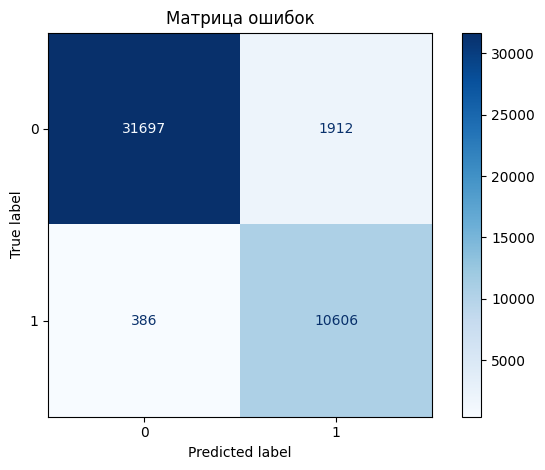

-----------------------------------------------------

 Основные результаты кросс-валидации (cv=5):
Средняя accuracy (CV): 0.9483
Стандартное отклонение accuracy (CV): 0.0012
Среднее precision (CV): 0.8484
Стандартное отклонение precision (CV): 0.0041
Среднее recall (CV): 0.9623
Стандартное отклонение recall (CV): 0.0023
Среднее f1 (CV): 0.9018
Стандартное отклонение f1 (CV): 0.0020
-----------------------------------------------------

 Дополнительные результаты кросс-валидации (cv=5):
Среднее roc_auc (CV): 0.9924
Среднее balanced_accuracy (CV): 0.9530
Тестовая оценка
Accuracy:          0.9485
Balanced Accuracy: 0.9540
Precision:         0.8473
Recall:            0.9649
F1-score:          0.9023


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

pipe_gb = Pipeline([
    ('smote', SMOTE(random_state=97)),
    ('model', GradientBoostingClassifier(
                random_state=42,
                n_estimators=100,
                learning_rate=0.1,
                max_depth=10,
                min_samples_split=10,
                min_samples_leaf=6,
                subsample=0.7,
                max_features='sqrt' ))
])

train_and_evaluate(pipe_gb)

#### SVM

Общий прогноз на тестовой выборке:

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.89      0.88      0.88     33609
           1       0.64      0.66      0.65     10992

    accuracy                           0.82     44601
   macro avg       0.76      0.77      0.76     44601
weighted avg       0.83      0.82      0.82     44601



<Figure size 800x500 with 0 Axes>

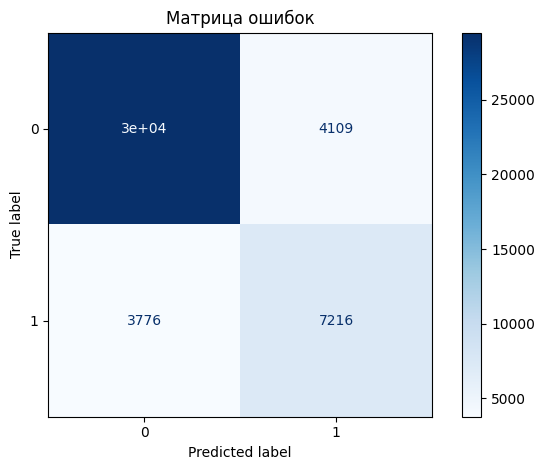

-----------------------------------------------------

 Основные результаты кросс-валидации (cv=5):
Средняя accuracy (CV): 0.8239
Стандартное отклонение accuracy (CV): 0.0015
Среднее precision (CV): 0.6396
Стандартное отклонение precision (CV): 0.0036
Среднее recall (CV): 0.6540
Стандартное отклонение recall (CV): 0.0032
Среднее f1 (CV): 0.6467
Стандартное отклонение f1 (CV): 0.0024
-----------------------------------------------------

 Дополнительные результаты кросс-валидации (cv=5):
Среднее roc_auc (CV): 0.8391
Среднее balanced_accuracy (CV): 0.7667
Тестовая оценка
Accuracy:          0.8232
Balanced Accuracy: 0.7671
Precision:         0.6372
Recall:            0.6565
F1-score:          0.6467


In [93]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import QuantileTransformer
from imblearn.over_sampling import SMOTE

pipe_svm = Pipeline([
    ('smote', SMOTE(random_state=97)),
    ('scaler', QuantileTransformer(output_distribution='normal')),
    ('model', LinearSVC(random_state=42))
])


train_and_evaluate(pipe_svm)


In [ ]:
'''

C=1 — параметр регуляризации.
 Чем меньше C, тем сильнее регуляризация (модель более простая, меньше переобучения). При C=1 — стандартное значение.

dual=False — решать исходную задачу (primal) вместо двойственной.
Обычно при большом количестве признаков и сравнительно небольшом количестве объектов выгоднее dual=False.

loss='squared_hinge' — функция потерь:
квадратный хинг-лиосс (обычно обеспечивает более гладкий градиент и может улучшить сходимость).

penalty='l2' — тип регуляризации: L2
 (среднее квадратичное) регуляризующее слагаемое для предотвращения переобучения.
'''


# from imblearn.pipeline import Pipeline  # Импортируем пайплайн из imblearn, а не из sklearn
# from imblearn.over_sampling import SMOTE
# from sklearn.preprocessing import StandardScaler
# from sklearn.svm import LinearSVC
# from sklearn.model_selection import GridSearchCV

# pipe = Pipeline([
#     ('smote', SMOTE(random_state=97))
#     ('scaler', StandardScaler()),
#     ('model', LinearSVC(random_state=42, max_iter=10000))
# ])

# param_grid = {
#     'scaler': [
#         StandardScaler(),
#         MinMaxScaler(),
#         RobustScaler(),
#         PowerTransformer(method='yeo-johnson'),
#         QuantileTransformer(output_distribution='normal')
#     ],
#     'model__C': [0.01, 0.1, 1, 10],
#     'model__loss': ['hinge', 'squared_hinge'],
#     'model__penalty': ['l2'],
#     'model__dual': [False],
# }

# grid_search = GridSearchCV(pipe, param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=2)
# grid_search.fit(x_train, y_train)

# print("Лучшие параметры:", grid_search.best_params_)
# print("Лучшее значение F1:", grid_search.best_score_)


#### Нейроная сеть 

Многослойный перцептрон (MLP)

Входной слой — 40 признаков <br>
Первый скрытый слой — 34 нейрона <br>
Dropout <br>
Второй скрытый слой — 6 нейронов <br>
Dropout <br>
Выходной слой —  1 нейрон с sigmoid <br>

In [63]:
%pip install tensorflow
from tensorflow.keras.layers import Dense, Dropout # type: ignore
from tensorflow import keras
print(x_train_nm.shape[1])

def create_model():
    model = keras.Sequential()
    model.add(Dense(64, activation='relu', input_shape=(x_train_nm.shape[1],)))
    model.add(Dropout(0.3))
    model.add(Dense(12, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    model.summary()
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    return model

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


41


##### Кросс-валидация

In [ ]:

def custom_cross_val(kfold, n_splits, x_train, y_train):

    accuracies = []
    precisions = []
    recalls = []
    f1_scores = []
    roc_aucs = []
    balanced_accuracies = []

    if kfold == kfold_ : # type: ignore
        val_split = kfold.split(x_train)

    elif kfold == kfold_stratified: # type: ignore
        val_split = kfold.split(x_train, y_train)


    for fold, (train_idx, val_idx) in enumerate(val_split):
        print(f"\nФолд {fold + 1}/{n_splits}")

        X_train_fold = x_train.iloc[train_idx]
        y_train_fold = y_train.iloc[train_idx]
        X_val_fold = x_train.iloc[val_idx]
        y_val_fold = y_train.iloc[val_idx]

        model = create_model()
        model.fit(X_train_fold, y_train_fold, epochs=5, batch_size=32, verbose=1, validation_data=(X_val_fold, y_val_fold))

        y_pred_prob = model.predict(X_val_fold).ravel()
        y_pred = (y_pred_prob > 0.5).astype(int)

        acc = accuracy_score(y_val_fold, y_pred)
        prec = precision_score(y_val_fold, y_pred)
        rec = recall_score(y_val_fold, y_pred)
        f1 = f1_score(y_val_fold, y_pred)
        bal_acc = balanced_accuracy_score(y_val_fold, y_pred)

        try:
            roc_auc = roc_auc_score(y_val_fold, y_pred_prob)
        except:
            roc_auc = float('nan')

        accuracies.append(acc)
        precisions.append(prec)
        recalls.append(rec)
        f1_scores.append(f1)
        balanced_accuracies.append(bal_acc)
        roc_aucs.append(roc_auc)

        print(f"Accuracy: {acc:.4f} | Balanced Acc: {bal_acc:.4f} | Precision: {prec:.4f} | \
              Recall: {rec:.4f} | F1: {f1:.4f} | ROC AUC: {roc_auc:.4f}")




    print("\nСредние значения по кросс-валидации:")
    print(f"Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
    print(f"Balanced Accuracy: {np.mean(balanced_accuracies):.4f} ± {np.std(balanced_accuracies):.4f}")
    print(f"Precision: {np.mean(precisions):.4f} ± {np.std(precisions):.4f}")
    print(f"Recall: {np.mean(recalls):.4f} ± {np.std(recalls):.4f}")
    print(f"F1-score: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
    print(f"ROC AUC: {np.mean(roc_aucs):.4f} ± {np.std(roc_aucs):.4f}")

In [78]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold

kfold_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kfold_ = KFold(n_splits=5, shuffle=True, random_state=42)
custom_cross_val(kfold_, 5, x_train_nm, y_train_nm)


Фолд 1/5


d:\Python Language\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 64)             │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 12)             │           780 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,481 (13.60 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 64)             │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 12)             │           780 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,481 (13.60 KB)

 Trainable params: 3,481 (13.60 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6316 - loss: 0.8651 - val_accuracy: 0.7914 - val_loss: 0.4533
Epoch 2/5
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7832 - loss: 0.4655 - val_accuracy: 0.8439 - val_loss: 0.3648
Epoch 3/5
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8314 - loss: 0.3676 - val_accuracy: 0.8748 - val_loss: 0.2557
Epoch 4/5
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8582 - loss: 0.2833 - val_accuracy: 0.8788 - val_loss: 0.2333
Epoch 5/5
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8648 - loss: 0.2554 - val_accuracy: 0.8835 - val_loss: 0.2238
321/321 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step
Accuracy: 0.8835 | Balanced Acc: 0.8835 | Precision: 0.8791 |               Recall: 0.8852 | F1: 0.8821 | ROC AUC: 0.9672

Средние значения по кросс-валидации:
Accuracy: 0.8879 ± 0.0067
Balanced Accuracy: 0.8881 ± 0.0068
Precision: 0.8786 ± 0.0239
Recall: 0.9016 ± 0.0224
F1-score: 0.8894 ± 0.0065
ROC AUC: 0.969

##### Снова обучение, но уже на всех данных

d:\Python Language\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_42 (Dense)                │ (None, 64)             │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 12)             │           780 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,481 (13.60 KB)

 Trainable params: 3,481 (13.60 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6777 - loss: 0.7323 - val_accuracy: 0.4536 - val_loss: 0.6590
Epoch 2/5
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7786 - loss: 0.4531 - val_accuracy: 0.6819 - val_loss: 0.4134
Epoch 3/5
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8330 - loss: 0.3329 - val_accuracy: 0.7604 - val_loss: 0.3634
Epoch 4/5
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8668 - loss: 0.2727 - val_accuracy: 0.8631 - val_loss: 0.2602
Epoch 5/5
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8825 - loss: 0.2448 - val_accuracy: 0.8258 - val_loss: 0.3005
1394/1394 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9190 - loss: 0.1722
1394/1394 ━━━━━━━━━━━━━━━━━━━━ 1s 837us/step
Test loss: 0.1730
Test accuracy: 0.9191
-------------------------------------------

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95     33609
           1    

<Figure size 800x500 with 0 Axes>

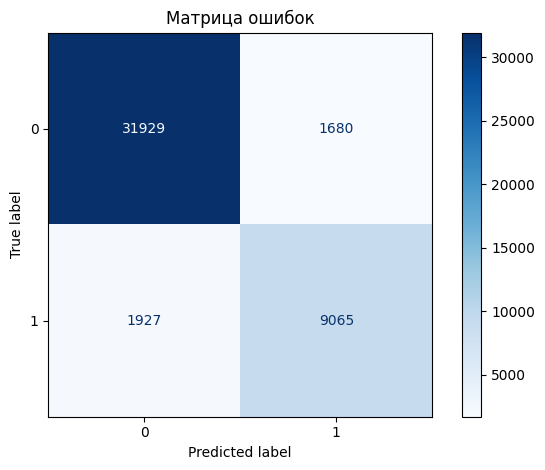

Accuracy:          0.9191
Balanced Accuracy: 0.8874
Precision:         0.8436
Recall:            0.8247
F1-score:          0.8341


In [97]:
model = create_model()
model.fit(x_train_nm, y_train_nm, batch_size=32, epochs=5, validation_split=0.2, shuffle=True)
loss, accuracy = model.evaluate(x_test, y_test)


y_pred_prob = model.predict(x_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

print(f"Test loss: {loss:.4f}")
print(f"Test accuracy: {accuracy:.4f}")

print('-------------------------------------------')
report(y_test, y_pred)
plot_confusion_matrix(y_test, y_pred)


bal_acc = balanced_accuracy_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:          {acc:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"Precision:         {prec:.4f}")
print(f"Recall:            {rec:.4f}")
print(f"F1-score:          {f1:.4f}")


Не смотреть. Локальная значимость признаков. (Ещё в работе)

In [67]:
# import lime
# import lime.lime_tabular
# import numpy as np

# def keras_predict_proba(X):
#     preds = model.predict(X)
#     preds = preds.reshape(-1)
#     probs = np.vstack([1 - preds, preds]).T
#     return probs


# def explainer_lime(x_train, y_train, num_features=15):

#     explainer = lime.lime_tabular.LimeTabularExplainer(
#         training_data=np.array(x_train),
#         feature_names=x_train.columns if hasattr(x_train, 'columns') else [f'feat_{i}' for i in range(x_train.shape[1])],
#         class_names=['0', '1'],
#         mode='classification'
#     )


#     i = 0
#     x = x_test.iloc[i]

#     exp = explainer.explain_instance(
#         data_row=x,
#         predict_fn=keras_predict_proba,
#         num_features=num_features
#     )

#     print(exp.as_list())

#     weights = dict(exp.as_list())
#     features = list(weights.keys())
#     importance = list(weights.values())

#     predicted_class = exp.predict_proba.argmax()
#     predicted_proba = exp.predict_proba[predicted_class]



#     colors = ['steelblue' if val >= 0 else 'salmon' for val in importance]
#     plt.figure(figsize=(9, 6))
#     bars = plt.barh(features, importance, color=colors)
#     plt.xlabel("Влияние признака")
#     plt.title(f"LIME объяснение для класса {predicted_class} (вероятность: {predicted_proba:.2f})")
#     plt.gca().invert_yaxis()
#     plt.grid(True, axis='x', linestyle='--', alpha=0.5)

#     for bar, val in zip(bars, importance):
#         plt.text(val + 0.02 if val >= 0 else val - 0.02, bar.get_y() + bar.get_height() / 2,
#                 f"{val:.2f}", va='center', ha='left' if val >= 0 else 'right')

#     plt.tight_layout()
#     plt.show()


# explainer_lime(x_train_nm, y_train_nm)

##### Sanity check для MLP

d:\Python Language\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 64)             │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 12)             │           780 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,481 (13.60 KB)

 Trainable params: 3,481 (13.60 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4960 - loss: 0.8291
Epoch 2/5
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4956 - loss: 0.6943
Epoch 3/5
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4988 - loss: 0.6934
Epoch 4/5
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4954 - loss: 0.6934
Epoch 5/5
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4988 - loss: 0.6932
Accuracy на случайной цели: 0.2465
1394/1394 ━━━━━━━━━━━━━━━━━━━━ 1s 881us/step

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     33609
           1       0.25      1.00      0.40     10992

    accuracy                           0.25     44601
   macro avg       0.12      0.50      0.20     44601
weighted avg       0.06      0.25      0.10     44601



d:\Python Language\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Python Language\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Python Language\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Figure size 800x500 with 0 Axes>

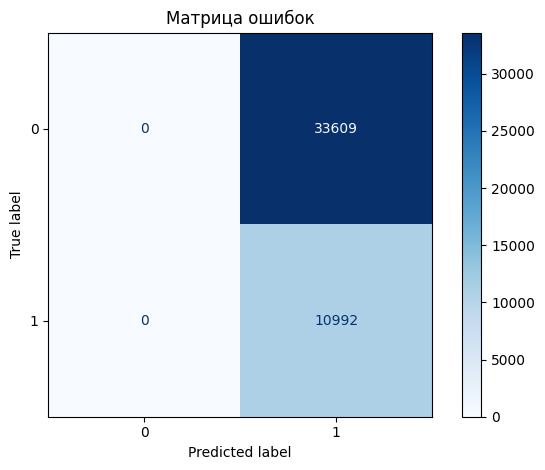

In [68]:
import numpy as np

y_train_random = np.random.permutation(y_train_nm)

model = create_model()
model.fit(x_train_nm, y_train_random, epochs=5, batch_size=32, verbose=1)

loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Accuracy на случайной цели: {acc:.4f}")

y_pred_probs = model.predict(x_test)
y_pred = (y_pred_probs > 0.5).astype(int)
report(y_test, y_pred)
plot_confusion_matrix(y_test, y_pred)


#### Ансамбль моделей

##### Bagging

Общий прогноз на тестовой выборке:

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     33609
           1       0.85      0.95      0.90     10992

    accuracy                           0.95     44601
   macro avg       0.92      0.95      0.93     44601
weighted avg       0.95      0.95      0.95     44601



<Figure size 800x500 with 0 Axes>

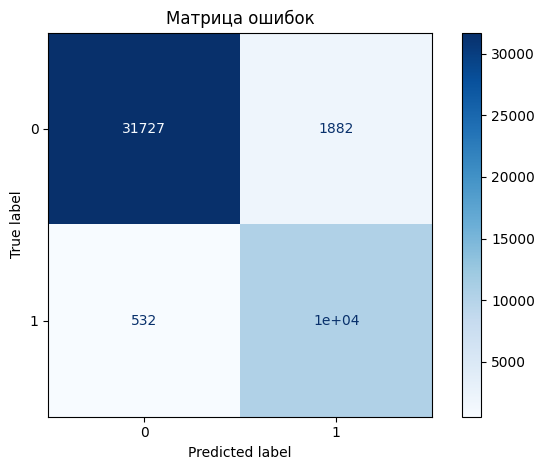

-----------------------------------------------------

 Основные результаты кросс-валидации (cv=5):
Средняя accuracy (CV): 0.9464
Стандартное отклонение accuracy (CV): 0.0016
Среднее precision (CV): 0.8497
Стандартное отклонение precision (CV): 0.0042
Среднее recall (CV): 0.9508
Стандартное отклонение recall (CV): 0.0025
Среднее f1 (CV): 0.8974
Стандартное отклонение f1 (CV): 0.0029
-----------------------------------------------------

 Дополнительные результаты кросс-валидации (cv=5):
Среднее roc_auc (CV): 0.9902
Среднее balanced_accuracy (CV): 0.9479
Тестовая оценка
Accuracy:          0.9459
Balanced Accuracy: 0.9478
Precision:         0.8475
Recall:            0.9516
F1-score:          0.8965


In [95]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
import math

base_model = DecisionTreeClassifier(
        random_state=42,
        criterion='entropy',
        min_samples_leaf=4,
        min_samples_split=10
    )

bagging = BaggingClassifier(

    estimator=base_model,
    n_estimators=10,     # количество базовых моделей
    max_samples=0.8,     # сколько данных брать для каждой модели (сэмплы с заменой)
    max_features=1.0,    # сколько признаков брать для каждой модели
    bootstrap=True,      # сэмплы с заменой (bootstrap)
    random_state=42
)

pipe_bagging = Pipeline([
    ('smote', SMOTE(random_state=97)),
    ('model', bagging)
])

train_and_evaluate(pipe_bagging, cv=5)

Voting (-)

Общий прогноз на тестовой выборке:


d:\Python Language\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Отчет о классификации:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     33609
           1       0.87      0.89      0.88     10992

    accuracy                           0.94     44601
   macro avg       0.92      0.92      0.92     44601
weighted avg       0.94      0.94      0.94     44601



<Figure size 800x500 with 0 Axes>

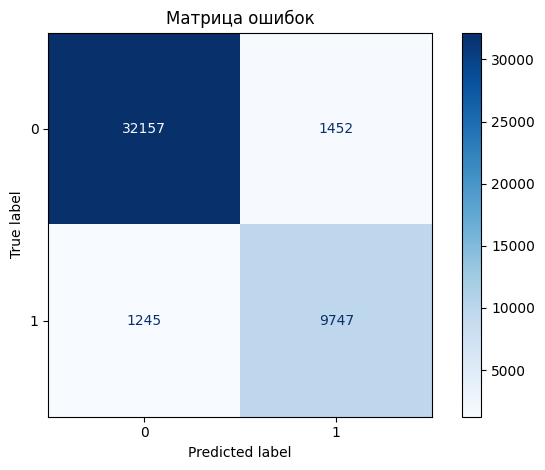

-----------------------------------------------------

 Основные результаты кросс-валидации (cv=5):


d:\Python Language\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
d:\Python Language\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_o

Средняя accuracy (CV): 0.9404
Стандартное отклонение accuracy (CV): 0.0023
Среднее precision (CV): 0.8662
Стандартное отклонение precision (CV): 0.0045
Среднее recall (CV): 0.8965
Стандартное отклонение recall (CV): 0.0049
Среднее f1 (CV): 0.8811
Стандартное отклонение f1 (CV): 0.0046
-----------------------------------------------------

 Дополнительные результаты кросс-валидации (cv=5):
Среднее roc_auc (CV): 0.9645
Среднее balanced_accuracy (CV): 0.9256


In [ ]:
# from sklearn.ensemble import VotingClassifier
# from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier

# model1 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
# model2 = DecisionTreeClassifier(
#         random_state=42,
#         criterion='entropy',
#         min_samples_leaf=4,
#         min_samples_split=10
#     )

# pipe_VT = Pipeline([
#     ('smote', SMOTE(random_state=97)),
#     ('model', VotingClassifier(estimators=[('lr', model1), ('dt', model2)], voting='soft'))
# ])

# train_and_evaluate(pipe_VT)

Stacking (-)

In [71]:
# from sklearn.ensemble import StackingClassifier
# from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.svm import LinearSVC
# from sklearn.neighbors import KNeighborsClassifier

# estimators = [
#     ('dt', DecisionTreeClassifier(random_state=42)),
#     ('svm', LinearSVC(random_state=42)),
#     ('knn', KNeighborsClassifier())
# ]


# final_estimator = LogisticRegression()

# stacking_clf = StackingClassifier(
#     estimators=estimators,
#     final_estimator=final_estimator,
#     cv=3,
#     stack_method='auto'
# )

# pipe_stacking = Pipeline([
#     ('smote', SMOTE(random_state=97)),
#     ('model', stacking_clf)
# ])

# train_and_evaluate(pipe_stacking, cv=2)

### 👿 12. Результаты обучения

<style>
    table { font-size: 13px; } /* Уменьшаем шрифт */
</style>

Валидационные оценки


| Модель (CV=5)         | Accuracy | Recall | Precision | F1    | ROC AUC | Balanced Accuracy |
|-----------------------|----------|--------|-----------|-------| ------- | ----------------- |
| One Rule              |    -  | -  |   -   |  - | - | -
| Логистическая регрессия | 0.8161  | 0.6624 | 0.6186     | 0.6397 | 0.8427  | 0.7644  |
| KNN                   |  0.8799  |0.8096     |  0.7316    |0.7686   | 0.9319 | 0.8562 |
| Дерево решений        | 0.9382        | 0.9038      | 0.8539        | 0.8781    | 0.9542  | 0.9266|
| Наивный Байес         | 0.8810        | 0.5763      | <span style="color:yellow">0.9072</span>          | 0.7047    |0.9539 | 0.7785
| Градиентный бустинг   | <span style="color:yellow">0.9483</span>         |  <span style="color:yellow">0.9623</span>        | 0.8484         |  <span style="color:yellow">0.9018</span>     | <span style="color:yellow">0.9924</span>  | <span style="color:yellow">0.9530</span> 
| SVM                   | 0.8240       | 0.6538     | 0.6398         | 0.6467     | 0.8390 |  0.7667 |
| MLP                   | 0.8879       | 0.9016     | 0.8786         | 0.8894     | 0.9693 | 0.8881
| Ансамбль (Bagging)    | 0.9464      | 0.9508     |  0.8497        | 0.8974    | 0.9902 | 0.9479

Тестовые оценки

| Модель               | Accuracy | Recall | Precision | F1     | Balanced Accuracy | Рейтинг по BA |
|----------------------|----------|--------|-----------|--------|-------------------| --------|
| One Rule             |  0.8576   | 0.4224 |<span style="color:yellow"> 1.0000 </span>   | 0.5939   | 0.7112           | 9 |
| Логистическая регрессия | 0.8166 | 0.6678 | 0.6184    | 0.6422 | 0.7665            |8
| KNN                  | 0.8824   | 0.8126 | 0.7372    | 0.7731 | 0.8589            | 5
| Дерево решений       | 0.9378   | 0.8965 | 0.8576    | 0.8766 | 0.9239            | 3
| Наивный Байес        | 0.8832   | 0.5885 | 0.9042    | 0.7130 | 0.7841            | 6
| Градиентный бустинг  |<span style="color:yellow"> 0.9485 </span>  | <span style="color:yellow">0.9649</span> | 0.8473    | <span style="color:yellow"> 0.9023 </span>  | <span style="color:yellow">0.9540</span>            | <span style="color:yellow">1</span>     
| SVM                  | 0.8232   | 0.6565 | 0.6372    | 0.6467 | 0.7671            | 7
| MLP                  | 0.9191   | 0.8247 | 0.8436    | 0.8341 | 0.8874            | 4
| Ансамбль (Bagging)   | 0.9459   | 0.9516 | 0.8475    | 0.8965 | 0.9478            | 2





Вывод налучшим моделям себя показали градиентный бустинг, (Ансамбль Bagging на основе деревьев (Случайны лес)) и сами деревья.

Лучшим признаком в модели One Rule стал credit_type_EQUI, его корреляция с целевой переменной составляла около 0.59. <br> Как я упоминал ранее, это могло быть частично связано с утечкой информации, но все же я решил, что это признак важен. <br>

Ранее я удалял признаки — искусственно созданные индикаторы пропусков, такие как rate_of_interest_missing и property_value_missing. <br>
Если их оставить, задача становится значительно проще, и таблица примерно принимает следующий вид:

<style>
    table { font-size: 13px; } /* Уменьшаем шрифт */
</style>


| Модель               | Accuracy | Recall | Precision | F1   | Balanced Accuracy | 
|----------------------|----------|--------|-----------|------|-------------------|
| One Rule             | 0.99     | 0.99   | 0.99      | 0.99 | 0.99              | 
| Логистическая регрессия | 0.99  | 0.99   | 0.99      | 0.99 | 0.99              | 
| KNN                  | 0.99     | 0.99   | 0.99      | 0.99 | 0.99              | 
| Дерево решений       | 0.99     | 0.99   | 0.99      | 0.99 | 0.99              | 
| Наивный Байес        | 0.99     | 0.99   | 0.99      | 0.99 | 0.99              | 
| Градиентный бустинг  | 0.99     | 0.99   | 0.99      | 0.99 | 0.99              | 
| SVM                  | 0.99     | 0.99   | 0.99      | 0.99 | 0.99              | 
| MLP                  | 0.99     | 0.99   | 0.99      | 0.99 | 0.99              | 
| Ансамбль (Bagging)   | 0.99     | 0.99   | 0.99      | 0.99 | 0.99              | 

В целом по датасету можно сказать, что пропуски могут играть ключевую роль в предсказательной силе моделей. <br> Очевидно, что существует определённая закономерность между пропусками и статусом кредита. Это также может быть связано с особенностями создания самого датасета.


In [ ]:
#Доп. препроцессинг. нашел в интернете. (скрыто)

# df.drop(columns = ['ID', 'year', 'loan_limit', 'loan_type',
#                    'loan_purpose', 'Credit_Worthiness', 'construction_type', 'credit_type',
#                    'co-applicant_credit_type', 'submission_of_application', 'dtir1'], axis = 1, inplace = True)

# df_cleaned = df.dropna(subset=['approv_in_adv', 'term','Neg_ammortization'])

# from sklearn.experimental import enable_iterative_imputer
# from sklearn.impute import IterativeImputer

# mice_imputer = IterativeImputer()

# df_cleaned.loc[:, ['property_value', 'income']] = mice_imputer.fit_transform(df_cleaned[['property_value', 'income']])

# df_cleaned['rate_of_interest'].fillna(df_cleaned['rate_of_interest'].mean(), inplace=True)

# df_cleaned['Interest_rate_spread'].fillna(df_cleaned['Interest_rate_spread'].mean(), inplace=True)

# mode_age = df_cleaned['age'].mode()[0]
# median_upfront = df_cleaned['Upfront_charges'].median()

# df_cleaned['age'].fillna(mode_age, inplace=True)
# df_cleaned['Upfront_charges'].fillna(median_upfront, inplace=True)

# df_cleaned.loc[df_cleaned['LTV'].isna(), 'LTV'] = (df_cleaned['loan_amount'] / df_cleaned['property_value']) * 100

# from sklearn.preprocessing import LabelEncoder

# columns_to_encode = [
#     'Gender', 'approv_in_adv', 'open_credit', 'business_or_commercial',
#     'Neg_ammortization', 'interest_only', 'lump_sum_payment',
#     'occupancy_type', 'Secured_by', 'total_units', 'age', 'Region',
#     'Security_Type'
# ]

# label_encoder = LabelEncoder()

# for col in columns_to_encode:
#     df_cleaned.loc[:, col] = label_encoder.fit_transform(df_cleaned[col])

# X = df_cleaned.drop(columns=['Status'])  # Features
# y = df_cleaned['Status']


# from sklearn.preprocessing import StandardScaler

# from sklearn.model_selection import train_test_split

# x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# scaler = StandardScaler()
# x_test = scaler.fit_transform(x_test)
# x_train = scaler.fit_transform(x_train)
